# **Aprendizaje por refuerzos** - FrozenLake y LunarLander (Gymnasium)

## Tarea: Implementar Agentes Q-Learning y DQN

### Objetivos:
1. Implementar el algoritmo Q-Learning
2. Implementar el algoritmo DQN
3. Entrenar y evaluar ambos agentes
4. Comparar el rendimiento de ambos enfoques


In [16]:
# Instalar paquetes requeridos
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

%pip install swig matplotlib gymnasium torch pygame


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [17]:
# Importar las bibliotecas
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pygame
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque, namedtuple
import random


La siguiente celda permite ejecutar un juego de Frozen Lake *determinista* para jugar con el teclado.

Utilize las teclas de dirección (flechas) o asdw para comandar al agente.


In [69]:
def jugar_frozen_lake(env):
    env.reset()
    
    print("Controles:")
    print("W - Arriba")
    print("S - Abajo") 
    print("A - Izquierda")
    print("D - Derecha")
    print("Q - Salir")
    print("Presione cualquier tecla para empezar...")
    
    pygame.init()
    pygame.display.set_caption("FrozenLake - Juego Interactivo")
    
    clock = pygame.time.Clock()
    ejecutando = True
    
    while ejecutando:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                ejecutando = False
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_q or event.key == pygame.K_ESCAPE:
                    ejecutando = False
                elif event.key == pygame.K_w or event.key == pygame.K_UP:
                    accion = 3  # Arriba
                elif event.key == pygame.K_s or event.key == pygame.K_DOWN:
                    accion = 1  # Abajo
                elif event.key == pygame.K_a or event.key == pygame.K_LEFT:
                    accion = 0  # Izquierda
                elif event.key == pygame.K_d or event.key == pygame.K_RIGHT:
                    accion = 2  # Derecha
                else:
                    continue
                
                observacion, recompensa, terminado, truncado, info = env.step(accion)
                print(f"Acción: {accion}, Recompensa: {recompensa}, Terminado: {terminado}")
                
                if terminado or truncado:
                    print(f"¡Episodio terminado! Recompensa final: {recompensa}")
                    pygame.time.wait(500)
                    env.reset()
        
        clock.tick(60)
    
    pygame.quit()
    env.close()

env = gym.make('FrozenLake-v1', render_mode='human', is_slippery=False)
# Descomente la línea de abajo para jugar interactivamente
# jugar_frozen_lake(env)


La siguiente celda permite jugar al juego no determinista.

In [129]:
env = gym.make('FrozenLake-v1', render_mode='human', is_slippery=True)
# Descomente la línea de abajo para jugar interactivamente
jugar_frozen_lake(env)

Controles:
W - Arriba
S - Abajo
A - Izquierda
D - Derecha
Q - Salir
Presione cualquier tecla para empezar...
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 3, Recompensa: 0, Terminado: False
Acción: 3, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 3, Recompensa: 0, Terminado: False
Acción: 3, Recompensa: 0, Terminado: False
Acción: 3, Recompensa: 0, Terminado: False
Acción: 3, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Terminado: False
Acción: 0, Recompensa: 0, Termi

La siguiente clase define la interfaz de los agentes que utilizaremos para jugar al Frozen Lake.


In [20]:
from abc import ABC, abstractmethod

class Agente(ABC):
    
    @abstractmethod
    def elegir_accion(self, estado):
        """Elige una acción dada una observación."""
        pass
    
    @abstractmethod
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Aprende de la experiencia."""
        pass

class AgenteAleatorio(Agente):
    """Agente aleatorio que elige acciones al azar."""
    
    def __init__(self, espacio_acciones):
        # Se guarda el espacio de acciones para poder elegir acciones al azar
        self.espacio_acciones = espacio_acciones
    
    def elegir_accion(self, estado):
        return self.espacio_acciones.sample()
    
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        pass  # El agente aleatorio no aprende

# Probar el AgenteAleatorio
env = gym.make('FrozenLake-v1')
agente_aleatorio = AgenteAleatorio(env.action_space)
estado, _ = env.reset()
accion = agente_aleatorio.elegir_accion(estado)
print(f"✓ AgenteAleatorio creado y probado. Acción: {accion}")
env.close()


✓ AgenteAleatorio creado y probado. Acción: 1


La siguiente celda define una función para evaluar el desempeño de un agente dado.

In [21]:
# Función de Evaluación de Agentes
def evaluar_agente(agente, env, num_episodios=1000):
    """
    Evalúa el rendimiento de un agente a lo largo de múltiples episodios.
    
    Args:
        agente: El agente a evaluar
        env: El entorno
        num_episodios: Número de episodios a ejecutar
    
    Returns:
        dict: Resultados de la evaluación
    """
    recompensas_totales = []
    victorias = 0
    
    for episodio in range(num_episodios):
        estado, _ = env.reset()
        recompensa_total = 0
        
        while True:
            accion = agente.elegir_accion(estado)
            estado, recompensa, terminado, truncado, _ = env.step(accion)
            recompensa_total += recompensa
            
            if terminado or truncado:
                break
        
        recompensas_totales.append(recompensa_total)
        if recompensa_total > 0:
            victorias += 1
    
    return {
        'recompensas_totales': recompensas_totales,
        'victorias': victorias,
        'tasa_victorias': victorias / num_episodios,
        'recompensa_promedio': np.mean(recompensas_totales),
        'desv_estandar': np.std(recompensas_totales)
    }

def imprimir_resultados_evaluacion(resultados, nombre_agente):
    """Imprime los resultados de evaluación de forma formateada."""
    print(f"\n{nombre_agente} - Resultados de Evaluación:")
    print(f"Tasa de Victorias: {resultados['tasa_victorias']:.1%}")
    print(f"Recompensa Promedio: {resultados['recompensa_promedio']:.3f}")
    print(f"Desviación Estándar: {resultados['desv_estandar']:.3f}")
    print(f"Total de Victorias: {resultados['victorias']}")

# Probar función de evaluación
env = gym.make('FrozenLake-v1')
agente_aleatorio = AgenteAleatorio(env.action_space)
resultados = evaluar_agente(agente_aleatorio, env, num_episodios=100)
imprimir_resultados_evaluacion(resultados, "Agente Aleatorio")
env.close()



Agente Aleatorio - Resultados de Evaluación:
Tasa de Victorias: 4.0%
Recompensa Promedio: 0.040
Desviación Estándar: 0.196
Total de Victorias: 4


La siguiente celda define una función para entrenar un agente.

In [22]:
# Función de Entrenamiento de Agentes
def entrenar_agente(agente, env, num_episodios=1000, max_pasos=100, verbose=True):
    """
    Entrena un agente en el entorno.
    
    Args:
        agente: El agente a entrenar
        env: El entorno
        num_episodios: Número de episodios de entrenamiento
        max_pasos: Máximo de pasos por episodio
        verbose: Si imprimir el progreso
    
    Returns:
        list: Recompensas de episodios
    """
    recompensas_episodios = []
    longitudes_episodios = []
    num_episodios_10 = int(num_episodios / 10)
    
    for episodio in range(num_episodios):
        estado, _ = env.reset()
        recompensa_total = 0
        pasos = 0
        
        for paso in range(max_pasos):
            accion = agente.elegir_accion(estado)
            siguiente_estado, recompensa, terminado, truncado, _ = env.step(accion)
            
            agente.aprender(estado, accion, recompensa, siguiente_estado, terminado or truncado)
            
            estado = siguiente_estado
            recompensa_total += recompensa
            pasos += 1
            
            if terminado or truncado:
                break
        
        recompensas_episodios.append(recompensa_total)
        longitudes_episodios.append(pasos)
        
        # Decaer epsilon si el agente tiene ese método
        if hasattr(agente, 'decaer_epsilon'):
            agente.decaer_epsilon()
        
        if verbose and (episodio + 1) % num_episodios_10 == 0:
            recompensa_promedio = np.mean(recompensas_episodios[-num_episodios_10:])
            longitud_promedio = np.mean(longitudes_episodios[-num_episodios_10:])
            epsilon_actual = getattr(agente, 'epsilon', 'N/A')
            print(f"Episodio {episodio + 1}: Recompensa Promedio = {recompensa_promedio:.3f}, Longitud Promedio = {longitud_promedio:.1f}, Epsilon = {epsilon_actual:.3f}")
    
    return recompensas_episodios, longitudes_episodios

print("✓ Funciones de entrenamiento definidas")


✓ Funciones de entrenamiento definidas


La siguiente celda define el agente de Q-Learning a implementar.

In [26]:
# TODO: Implementar Agente Q-Learning
class AgenteQLearning(Agente):
    """Agente que usa el algoritmo Q-Learning."""
    
    def __init__(self, observation_space_n, action_space_n, alpha, gamma, epsilon, epsilon_decay):
        """
        Inicializa el agente Q-Learning.

        Args:
            observation_space_n (int): Número de estados posibles.
            action_space_n (int): Número de acciones posibles.
            alpha (float): Tasa de aprendizaje.
            gamma (float): Factor de descuento.
            epsilon (float): Probabilidad inicial de exploración (epsilon-greedy).
            epsilon_decay (float): Cantidad fija a disminuir epsilon por episodio.
        """
        self.qtable = np.zeros((observation_space_n, action_space_n)) 
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.action_space_n = action_space_n # Guardamos el número de acciones
    
    def elegir_accion(self, estado):
        """Elige una acción usando política epsilon-greedy."""
        # Decaimiento de epsilon se maneja en el bucle de entrenamiento,
        # pero aquí usamos el valor actual de epsilon.
        if random.uniform(0, 1) < self.epsilon:
            # Exploración: elige una acción aleatoria
            return random.randint(0, self.action_space_n - 1)
        else:
            # Explotación: elige la acción con el valor Q más alto para el estado actual
            return np.argmax(self.qtable[estado, :])
    
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Actualiza la tabla Q usando la ecuación de Bellman."""
        # Q(s,a) = Q(s,a) + alpha * [recompensa + gamma * max(Q(s',a')) - Q(s,a)]
        
        # Si el episodio terminó, no hay siguiente estado del cual aprender (max Q(s',a') es 0)
        if terminado:
            target = recompensa
        else:
            target = recompensa + self.gamma * np.max(self.qtable[siguiente_estado, :])
        
        self.qtable[estado, accion] = self.qtable[estado, accion] + \
                                       self.alpha * (target - self.qtable[estado, accion])
    
    def decaer_epsilon(self):
        """Reduce el valor de epsilon para disminuir la exploración con el tiempo."""
        self.epsilon = max(0.01, self.epsilon - self.epsilon_decay) # Aseguramos que epsilon no baje de 0.01 para algo de exploración


Aqui deberán incluir código para entrenar y evaluar el agente de Q-Learning implementado.

In [75]:
# 🧪 Sistema de Experimentación Automática con Hiperparámetros

import pandas as pd
from datetime import datetime
import time

def experimento_hiperparametros(configuraciones, episodios_rapidos=15000, episodios_evaluacion=1000, verbose=True):
    """
    Ejecuta múltiples experimentos con diferentes configuraciones de hiperparámetros.
    
    Args:
        configuraciones: Lista de diccionarios con hiperparámetros
        episodios_rapidos: Episodios de entrenamiento (menos para experimentos rápidos)
        episodios_evaluacion: Episodios para evaluación
        verbose: Si mostrar progreso
    
    Returns:
        DataFrame con resultados de todos los experimentos
    """
    resultados = []
    num_pasos = 92  # Número máximo de pasos por episodio en entorno resbaladizo
    for i, config in enumerate(configuraciones):
        if verbose:
            print(f"\n🧪 EXPERIMENTO {i+1}/{len(configuraciones)}")
            print(f"   Configuración: α={config['alpha']}, γ={config['gamma']}, "
                  f"ε_decay={config['epsilon_decay']:.6f}")
        
        # Crear entorno fresco
        env_exp = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
        
        # Crear agente con configuración específica
        agente_exp = AgenteQLearning(
            observation_space_n=env_exp.observation_space.n,
            action_space_n=env_exp.action_space.n,
            alpha=config['alpha'],
            gamma=config['gamma'],
            epsilon=config.get('epsilon', 1.0),
            epsilon_decay=config['epsilon_decay']
        )
        
        # Entrenar
        inicio = time.time()
        recompensas_exp, _ = entrenar_agente(
            agente_exp, env_exp, 
            num_episodios=episodios_rapidos,
            max_pasos=num_pasos,
            verbose=False
        )
        tiempo_entrenamiento = time.time() - inicio
        
        # Evaluar
        resultados_eval = evaluar_agente(agente_exp, env_exp, num_episodios=episodios_evaluacion)
        
        # Guardar resultados
        resultado = {
            'experimento': i+1,
            'alpha': config['alpha'],
            'gamma': config['gamma'],
            'epsilon_decay': config['epsilon_decay'],
            'episodios': episodios_rapidos,
            'tasa_exito': resultados_eval['tasa_victorias'],
            'recompensa_promedio': resultados_eval['recompensa_promedio'],
            'desviacion_std': resultados_eval['desv_estandar'],
            'tiempo_entrenamiento': tiempo_entrenamiento,
            'mejora_final_1000': np.mean(recompensas_exp[-1000:]) if len(recompensas_exp) >= 1000 else np.mean(recompensas_exp),
            'valor_q_max': np.max(agente_exp.qtable),
            'valor_q_promedio': np.mean(agente_exp.qtable[agente_exp.qtable > 0])
        }
        
        resultados.append(resultado)
        env_exp.close()
        
        if verbose:
            print(f"   ✅ Tasa de éxito: {resultado['tasa_exito']:.1%}")
            print(f"   ⏱️  Tiempo: {tiempo_entrenamiento:.1f}s")
    
    return pd.DataFrame(resultados)

# 🎯 Definir configuraciones experimentales
configuraciones_experimentales = [
    # Experimento 1: Baseline (configuración actual)
    {'alpha': 0.5, 'gamma': 0.95, 'epsilon_decay': 0.0000198},
    
    # Experimento 2: Alpha más alto (aprendizaje más agresivo)
    {'alpha': 0.8, 'gamma': 0.967, 'epsilon_decay': 0.0000198},
    
    # Experimento 3: Gamma más alto (más importancia al futuro)
    {'alpha': 0.5, 'gamma': 0.99, 'epsilon_decay': 0.0000198},
    
    # Experimento 4: Epsilon decay más lento (más exploración)
    {'alpha': 0.5, 'gamma': 0.95, 'epsilon_decay': 0.00001},
    
    # Experimento 5: Combinación agresiva
    {'alpha': 0.8, 'gamma': 0.99, 'epsilon_decay': 0.00001},
    
    # Experimento 6: Alpha muy alto + gamma máximo
    {'alpha': 0.775, 'gamma': 0.99, 'epsilon_decay': 0.000005},
    
    # Experimento 7: Configuración conservadora pero persistente
    {'alpha': 0.91, 'gamma': 0.98, 'epsilon_decay': 0.000008},
    
    # Experimento 8: Balance optimizado
    {'alpha': 0.72, 'gamma': 0.97, 'epsilon_decay': 0.000012},
    
    # 🆕 Experimento 9: Tu configuración sugerida
    {'alpha': 0.8, 'gamma': 0.95, 'epsilon_decay': 0.000132},
    
    # 🆕 Experimento 10: Tu configuración con epsilon decay calculado para 15K episodios
    # Para 15,000 episodios: epsilon_decay = (1.0 - 0.01) / 15000 = 0.000066
    {'alpha': 0.8, 'gamma': 0.95, 'epsilon_decay': 0.000066},

    # 🆕 Experimento 11: Tu configuración sugerida 2
    {'alpha': 0.81, 'gamma': 0.945, 'epsilon_decay': 0.001},

    # 🆕 Experimento 12: Tu configuración sugerida 2
    {'alpha': 0.798, 'gamma': 0.9945, 'epsilon_decay': 0.000200},

    # Experimento 13: Configuración conservadora pero persistente
    {'alpha': 0.781, 'gamma': 0.9945, 'epsilon_decay': 0.0000330},

    # Experimento 14: Configuración conservadora pero persistente
    {'alpha': 0.831, 'gamma': 0.9945, 'epsilon_decay': 0.0000233},
]

print("🚀 Iniciando experimentos con diferentes hiperparámetros...")
print(f"📊 Total de configuraciones a probar: {len(configuraciones_experimentales)}")
print("⚡ Usando entrenamiento rápido (10,000 episodios) para acelerar experimentos")

# Ejecutar experimentos
resultados_experimentos = experimento_hiperparametros(
    configuraciones_experimentales, 
    episodios_rapidos=20000,  # Reducido para experimentos más rápidos
    episodios_evaluacion=1000
)

🚀 Iniciando experimentos con diferentes hiperparámetros...
📊 Total de configuraciones a probar: 14
⚡ Usando entrenamiento rápido (10,000 episodios) para acelerar experimentos

🧪 EXPERIMENTO 1/14
   Configuración: α=0.5, γ=0.95, ε_decay=0.000020
   ✅ Tasa de éxito: 4.4%
   ⏱️  Tiempo: 2.0s

🧪 EXPERIMENTO 2/14
   Configuración: α=0.8, γ=0.967, ε_decay=0.000020
   ✅ Tasa de éxito: 4.4%
   ⏱️  Tiempo: 2.0s

🧪 EXPERIMENTO 2/14
   Configuración: α=0.8, γ=0.967, ε_decay=0.000020
   ✅ Tasa de éxito: 2.3%
   ⏱️  Tiempo: 2.0s

🧪 EXPERIMENTO 3/14
   Configuración: α=0.5, γ=0.99, ε_decay=0.000020
   ✅ Tasa de éxito: 2.3%
   ⏱️  Tiempo: 2.0s

🧪 EXPERIMENTO 3/14
   Configuración: α=0.5, γ=0.99, ε_decay=0.000020
   ✅ Tasa de éxito: 6.1%
   ⏱️  Tiempo: 2.1s

🧪 EXPERIMENTO 4/14
   Configuración: α=0.5, γ=0.95, ε_decay=0.000010
   ✅ Tasa de éxito: 6.1%
   ⏱️  Tiempo: 2.1s

🧪 EXPERIMENTO 4/14
   Configuración: α=0.5, γ=0.95, ε_decay=0.000010
   ✅ Tasa de éxito: 1.5%
   ⏱️  Tiempo: 1.9s

🧪 EXPERIMENTO 5/1


📈 RESULTADOS DE EXPERIMENTOS (ordenados por tasa de éxito)

🏆 TOP 3 MEJORES CONFIGURACIONES:
------------------------------------------------------------

1. 🥇 Experimento 12.0
   📊 Tasa de éxito: 67.7%
   ⚙️  α=0.798, γ=0.9945, ε_decay=0.000200
   ⏱️  Tiempo: 9.3s
   📈 Mejora final: 0.436

2. 🥇 Experimento 10.0
   📊 Tasa de éxito: 51.1%
   ⚙️  α=0.8, γ=0.95, ε_decay=0.000066
   ⏱️  Tiempo: 4.4s
   📈 Mejora final: 0.512

3. 🥇 Experimento 9.0
   📊 Tasa de éxito: 47.4%
   ⚙️  α=0.8, γ=0.95, ε_decay=0.000132
   ⏱️  Tiempo: 6.7s
   📈 Mejora final: 0.473

🎯 CONFIGURACIONES QUE SUPERAN 50% DE ÉXITO:
--------------------------------------------------
✅ Exp 12.0: 67.7% (α=0.798, γ=0.9945, ε_decay=0.000200)
✅ Exp 10.0: 51.1% (α=0.8, γ=0.95, ε_decay=0.000066)


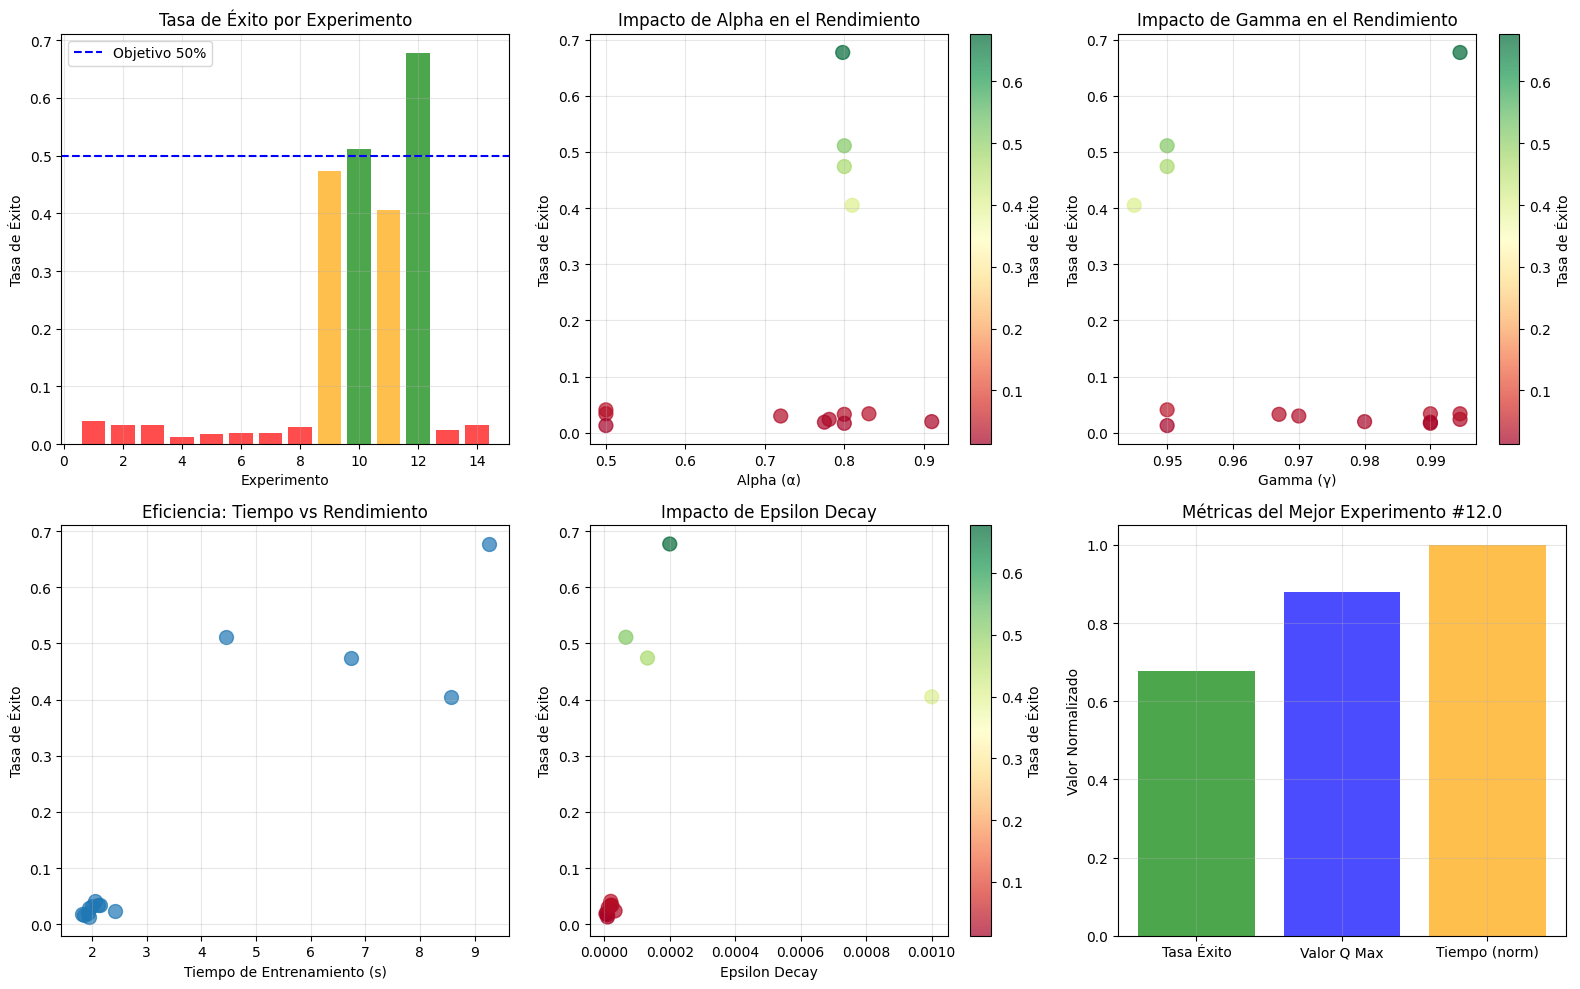


📋 TABLA COMPLETA DE RESULTADOS:
------------------------------------------------------------------------------------------------------------------------
 experimento  alpha  gamma  epsilon_decay  tasa_exito  tiempo_entrenamiento  valor_q_max
          12  0.798 0.9945         0.0002       0.677                9.2633       0.8806
          10  0.800 0.9500         0.0001       0.511                4.4439       0.9967
           9  0.800 0.9500         0.0001       0.474                6.7321       0.9096
          11  0.810 0.9450         0.0010       0.405                8.5688       0.8005
           1  0.500 0.9500         0.0000       0.041                2.0448       0.8201
           3  0.500 0.9900         0.0000       0.034                2.1416       0.9056
          14  0.831 0.9945         0.0000       0.034                2.1137       0.9796
           2  0.800 0.9670         0.0000       0.033                1.9985       0.8719
           8  0.720 0.9700         0.0000    

In [34]:
# 📊 Análisis de Resultados de Experimentos

# Mostrar resultados ordenados por tasa de éxito
print("\n" + "="*80)
print("📈 RESULTADOS DE EXPERIMENTOS (ordenados por tasa de éxito)")
print("="*80)

resultados_ordenados = resultados_experimentos.sort_values('tasa_exito', ascending=False)

print(f"\n🏆 TOP 3 MEJORES CONFIGURACIONES:")
print("-"*60)
for i, (idx, row) in enumerate(resultados_ordenados.head(3).iterrows()):
    print(f"\n{i+1}. 🥇 Experimento {row['experimento']}")
    print(f"   📊 Tasa de éxito: {row['tasa_exito']:.1%}")
    print(f"   ⚙️  α={row['alpha']}, γ={row['gamma']}, ε_decay={row['epsilon_decay']:.6f}")
    print(f"   ⏱️  Tiempo: {row['tiempo_entrenamiento']:.1f}s")
    print(f"   📈 Mejora final: {row['mejora_final_1000']:.3f}")

# Identificar configuraciones que superan el 50%
exito_50_plus = resultados_ordenados[resultados_ordenados['tasa_exito'] > 0.5]

print(f"\n🎯 CONFIGURACIONES QUE SUPERAN 50% DE ÉXITO:")
print("-"*50)
if len(exito_50_plus) > 0:
    for idx, row in exito_50_plus.iterrows():
        print(f"✅ Exp {row['experimento']}: {row['tasa_exito']:.1%} "
              f"(α={row['alpha']}, γ={row['gamma']}, ε_decay={row['epsilon_decay']:.6f})")
else:
    print("❌ Ninguna configuración superó el 50% con 10,000 episodios")
    print("💡 Recomendación: Entrenar la mejor configuración con más episodios")

# Visualización de resultados
plt.figure(figsize=(16, 10))

# Gráfico 1: Tasa de éxito por experimento
plt.subplot(2, 3, 1)
colores = ['green' if x > 0.5 else 'red' if x < 0.3 else 'orange' for x in resultados_experimentos['tasa_exito']]
plt.bar(resultados_experimentos['experimento'], resultados_experimentos['tasa_exito'], 
        color=colores, alpha=0.7)
plt.axhline(y=0.5, color='blue', linestyle='--', label='Objetivo 50%')
plt.title('Tasa de Éxito por Experimento')
plt.xlabel('Experimento')
plt.ylabel('Tasa de Éxito')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Relación Alpha vs Tasa de Éxito
plt.subplot(2, 3, 2)
plt.scatter(resultados_experimentos['alpha'], resultados_experimentos['tasa_exito'], 
           s=100, alpha=0.7, c=resultados_experimentos['tasa_exito'], cmap='RdYlGn')
plt.xlabel('Alpha (α)')
plt.ylabel('Tasa de Éxito')
plt.title('Impacto de Alpha en el Rendimiento')
plt.colorbar(label='Tasa de Éxito')
plt.grid(True, alpha=0.3)

# Gráfico 3: Relación Gamma vs Tasa de Éxito
plt.subplot(2, 3, 3)
plt.scatter(resultados_experimentos['gamma'], resultados_experimentos['tasa_exito'], 
           s=100, alpha=0.7, c=resultados_experimentos['tasa_exito'], cmap='RdYlGn')
plt.xlabel('Gamma (γ)')
plt.ylabel('Tasa de Éxito')
plt.title('Impacto de Gamma en el Rendimiento')
plt.colorbar(label='Tasa de Éxito')
plt.grid(True, alpha=0.3)

# Gráfico 4: Tiempo de entrenamiento vs Tasa de éxito
plt.subplot(2, 3, 4)
plt.scatter(resultados_experimentos['tiempo_entrenamiento'], resultados_experimentos['tasa_exito'], 
           s=100, alpha=0.7)
plt.xlabel('Tiempo de Entrenamiento (s)')
plt.ylabel('Tasa de Éxito')
plt.title('Eficiencia: Tiempo vs Rendimiento')
plt.grid(True, alpha=0.3)

# Gráfico 5: Epsilon Decay vs Tasa de Éxito
plt.subplot(2, 3, 5)
plt.scatter(resultados_experimentos['epsilon_decay'], resultados_experimentos['tasa_exito'], 
           s=100, alpha=0.7, c=resultados_experimentos['tasa_exito'], cmap='RdYlGn')
plt.xlabel('Epsilon Decay')
plt.ylabel('Tasa de Éxito')
plt.title('Impacto de Epsilon Decay')
plt.colorbar(label='Tasa de Éxito')
plt.grid(True, alpha=0.3)

# Gráfico 6: Comparación de métricas del mejor experimento
plt.subplot(2, 3, 6)
mejor_exp = resultados_ordenados.iloc[0]
metricas = ['Tasa Éxito', 'Valor Q Max', 'Tiempo (norm)']
valores = [mejor_exp['tasa_exito'], 
          mejor_exp['valor_q_max']/1.0,  # Normalizar
          mejor_exp['tiempo_entrenamiento']/max(resultados_experimentos['tiempo_entrenamiento'])]

plt.bar(metricas, valores, color=['green', 'blue', 'orange'], alpha=0.7)
plt.title(f'Métricas del Mejor Experimento #{mejor_exp["experimento"]}')
plt.ylabel('Valor Normalizado')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen completa
print(f"\n📋 TABLA COMPLETA DE RESULTADOS:")
print("-"*120)
print(resultados_ordenados[['experimento', 'alpha', 'gamma', 'epsilon_decay', 'tasa_exito', 
                           'tiempo_entrenamiento', 'valor_q_max']].round(4).to_string(index=False))

# Recomendaciones
print(f"\n💡 RECOMENDACIONES PARA MEJORAR:")
print("-"*50)
mejor_config = resultados_ordenados.iloc[0]

if mejor_config['tasa_exito'] > 0.5:
    print(f"🎉 ¡ÉXITO! La configuración {mejor_config['experimento']} logró {mejor_config['tasa_exito']:.1%}")
    print(f"📋 Configuración ganadora: α={mejor_config['alpha']}, γ={mejor_config['gamma']}, ε_decay={mejor_config['epsilon_decay']:.6f}")
else:
    print(f"⚠️  La mejor configuración alcanzó {mejor_config['tasa_exito']:.1%}")
    print(f"🔧 Sugerencias para mejorar:")
    print(f"   1. Entrenar la mejor configuración con 50,000+ episodios")
    print(f"   2. Probar α={min(0.95, mejor_config['alpha'] + 0.1)}, γ={min(0.99, mejor_config['gamma'] + 0.02)}")
    print(f"   3. Usar epsilon decay aún más lento: {mejor_config['epsilon_decay'] * 0.5:.7f}")

print(f"\n🎯 PRÓXIMO PASO: Entrenar la mejor configuración con más episodios")

## 🧭 Hiperparámetros clave para FrozenLake con lago resbaladizo (no determinista)

Para superar ~60% de tasa de victorias en el entorno estocástico, estos son los hiperparámetros más influyentes y cómo ajustarlos:

- Alpha (α, learning rate):
  - Alto (0.7–0.95) acelera aprendizaje pero puede ser inestable en estocástico.
  - Medio (0.5–0.7) más estable cuando hay ruido. Recomendación: 0.6–0.9 con evaluación.
- Gamma (γ, descuento):
  - 0.98–0.995 para valorar trayectorias largas y meta tardía.
- Epsilon decay (ε_decay, lineal):
  - Mucho más lento que en determinista, para seguir explorando por miles de episodios.
  - Recomendación: apuntar a 33–50% del entrenamiento por encima de ε_min=0.01.
- Episodios totales:
  - 50k–150k en 4x4 resbaladizo; más si la señal de recompensa es muy escasa.
- Max pasos por episodio:
  - 150–250 para permitir caminos más largos.

Por qué el lago resbaladizo complica el problema:
- Transiciones estocásticas: la acción elegida no siempre se ejecuta; necesitas ver muchas muestras → más exploración y episodios.
- Valores Q ruidosos: conviene γ alto y (opcionalmente) α más moderado.
- Convergencia más lenta: decay demasiado rápido bloquea aprendizaje (ε ≈ 0.01 demasiado pronto).

Consejos prácticos para >60%:
- Usa γ ∈ [0.99, 0.995], α ∈ [0.6, 0.9].
- Asegura que ε tarda 5k–10k episodios en llegar a 0.01 (para 15k–100k total, ajusta proporcional).
- Aumenta max_pasos a 200–250.
- Evalúa por ventanas (moving average) y permite entrenamiento largo (≥100k).

In [58]:
# 🧪 Configuraciones recomendadas para FrozenLake resbaladizo (objetivo ≥60%)

from pprint import pprint

def epsilon_decay_por_porcentaje(episodios_totales, porcentaje_exploracion, epsilon_inicial=1.0, epsilon_min=0.01):
    """Devuelve epsilon_decay para mantener ε > ε_min durante 'porcentaje_exploracion'% del entrenamiento."""
    ep_explorar = max(1, int(episodios_totales * (porcentaje_exploracion/100)))
    return (epsilon_inicial - epsilon_min) / ep_explorar

EPISODIOS_80K = 80000
EPISODIOS_100K = 100000
EPISODIOS_120K = 120000
EPISODIOS_150K = 150000

MAX_PASOS_RECOMENDADO = 200

configuraciones_experimentales_slippery = [
    # Balance 50% exploración, 100k episodios
    {
        'nombre': 'A1: α=0.9, γ=0.99, 50% expl, 100k',
        'alpha': 0.9, 'gamma': 0.99,
        'epsilon_decay': epsilon_decay_por_porcentaje(EPISODIOS_100K, 50),
        'episodios': EPISODIOS_100K, 'max_pasos': MAX_PASOS_RECOMENDADO
    },
    # Más estable (α moderado) y γ alto, 50% exploración, 150k
    {
        'nombre': 'A2: α=0.7, γ=0.995, 50% expl, 150k',
        'alpha': 0.7, 'gamma': 0.995,
        'epsilon_decay': epsilon_decay_por_porcentaje(EPISODIOS_150K, 50),
        'episodios': EPISODIOS_150K, 'max_pasos': MAX_PASOS_RECOMENDADO
    },
    # Más balanceado (33% exploración), 100k
    {
        'nombre': 'B1: α=0.8, γ=0.99, 33% expl, 100k',
        'alpha': 0.8, 'gamma': 0.99,
        'epsilon_decay': epsilon_decay_por_porcentaje(EPISODIOS_100K, 33),
        'episodios': EPISODIOS_100K, 'max_pasos': MAX_PASOS_RECOMENDADO
    },
    # Exploración prolongada (70%), 120k
    {
        'nombre': 'B2: α=0.75, γ=0.992, 70% expl, 120k',
        'alpha': 0.75, 'gamma': 0.992,
        'epsilon_decay': epsilon_decay_por_porcentaje(EPISODIOS_120K, 70),
        'episodios': EPISODIOS_120K, 'max_pasos': MAX_PASOS_RECOMENDADO
    },
    # Moderado y rápido (33% exploración), 80k (para probar más rápido)
    {
        'nombre': 'C1: α=0.85, γ=0.99, 33% expl, 80k',
        'alpha': 0.85, 'gamma': 0.99,
        'epsilon_decay': epsilon_decay_por_porcentaje(EPISODIOS_80K, 33),
        'episodios': EPISODIOS_80K, 'max_pasos': MAX_PASOS_RECOMENDADO
    },
    # Conservador en α, muy alto γ, 50% exploración, 100k
    {
        'nombre': 'C2: α=0.6, γ=0.995, 50% expl, 100k',
        'alpha': 0.6, 'gamma': 0.995,
        'epsilon_decay': epsilon_decay_por_porcentaje(EPISODIOS_100K, 50),
        'episodios': EPISODIOS_100K, 'max_pasos': MAX_PASOS_RECOMENDADO
    },
]

print('📋 Configuraciones propuestas (objetivo ≥60% en 4x4 resbaladizo):')
pprint(configuraciones_experimentales_slippery)

# Nota: para usarlas con tu experimento, puedes reemplazar/combinar con tu lista
# configuraciones_experimentales = [
#     { 'alpha': cfg['alpha'], 'gamma': cfg['gamma'], 'epsilon_decay': cfg['epsilon_decay']}
#     for cfg in configuraciones_experimentales_slippery
# ]
# y ajustar episodios/max_pasos al llamar entrenar_agente.


📋 Configuraciones propuestas (objetivo ≥60% en 4x4 resbaladizo):
[{'alpha': 0.9,
  'episodios': 100000,
  'epsilon_decay': 1.98e-05,
  'gamma': 0.99,
  'max_pasos': 200,
  'nombre': 'A1: α=0.9, γ=0.99, 50% expl, 100k'},
 {'alpha': 0.7,
  'episodios': 150000,
  'epsilon_decay': 1.32e-05,
  'gamma': 0.995,
  'max_pasos': 200,
  'nombre': 'A2: α=0.7, γ=0.995, 50% expl, 150k'},
 {'alpha': 0.8,
  'episodios': 100000,
  'epsilon_decay': 3e-05,
  'gamma': 0.99,
  'max_pasos': 200,
  'nombre': 'B1: α=0.8, γ=0.99, 33% expl, 100k'},
 {'alpha': 0.75,
  'episodios': 120000,
  'epsilon_decay': 1.1785714285714286e-05,
  'gamma': 0.992,
  'max_pasos': 200,
  'nombre': 'B2: α=0.75, γ=0.992, 70% expl, 120k'},
 {'alpha': 0.85,
  'episodios': 80000,
  'epsilon_decay': 3.75e-05,
  'gamma': 0.99,
  'max_pasos': 200,
  'nombre': 'C1: α=0.85, γ=0.99, 33% expl, 80k'},
 {'alpha': 0.6,
  'episodios': 100000,
  'epsilon_decay': 1.98e-05,
  'gamma': 0.995,
  'max_pasos': 200,
  'nombre': 'C2: α=0.6, γ=0.995, 50% 

In [59]:
# ⚡ Validación rápida de configuraciones (slippery 4x4)

import pandas as pd
import time

print("⚡ Ejecutando validación rápida (entrenamiento corto) ...")

resultados_quick = []
train_episodios = 2000   # corto para validación rápida
eval_episodios = 500
max_pasos = 200

for cfg in configuraciones_experimentales_slippery:
    env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
    agente = AgenteQLearning(
        observation_space_n=env.observation_space.n,
        action_space_n=env.action_space.n,
        alpha=cfg['alpha'],
        gamma=cfg['gamma'],
        epsilon=1.0,
        epsilon_decay=cfg['epsilon_decay']
    )

    t0 = time.time()
    entrenar_agente(agente, env, num_episodios=train_episodios, max_pasos=max_pasos, verbose=False)
    tiempo = time.time() - t0

    res = evaluar_agente(agente, env, num_episodios=eval_episodios)
    env.close()

    resultados_quick.append({
        'nombre': cfg['nombre'],
        'alpha': cfg['alpha'],
        'gamma': cfg['gamma'],
        'epsilon_decay': cfg['epsilon_decay'],
        'tasa_victorias': res['tasa_victorias'],
        'recompensa_promedio': res['recompensa_promedio'],
        'tiempo_s': tiempo,
        'episodios_train': train_episodios,
        'episodios_eval': eval_episodios,
        'max_pasos': max_pasos
    })

# Mostrar resumen ordenado por tasa de victorias
dfq = pd.DataFrame(resultados_quick).sort_values('tasa_victorias', ascending=False)
print("\n📊 Resultados (ordenados por tasa de victorias):")
print(dfq[['nombre','alpha','gamma','epsilon_decay','tasa_victorias','recompensa_promedio','tiempo_s']].to_string(index=False))

mejor = dfq.iloc[0]
print("\n🥇 Mejor en validación rápida:")
print(f"   {mejor['nombre']} | tasa={mejor['tasa_victorias']:.1%}, γ={mejor['gamma']}, α={mejor['alpha']}, ε_decay={mejor['epsilon_decay']:.6f}")

print("\nℹ️ Nota: Esta es una validación corta (2k episodios).")
print("   Los rankings pueden cambiar con entrenamientos largos (≥100k).")

⚡ Ejecutando validación rápida (entrenamiento corto) ...

📊 Resultados (ordenados por tasa de victorias):
                             nombre  alpha  gamma  epsilon_decay  tasa_victorias  recompensa_promedio  tiempo_s
  C1: α=0.85, γ=0.99, 33% expl, 80k   0.85  0.990       0.000037           0.020                0.020  0.181405
  B1: α=0.8, γ=0.99, 33% expl, 100k   0.80  0.990       0.000030           0.016                0.016  0.180505
B2: α=0.75, γ=0.992, 70% expl, 120k   0.75  0.992       0.000012           0.014                0.014  0.175050
 C2: α=0.6, γ=0.995, 50% expl, 100k   0.60  0.995       0.000020           0.012                0.012  0.182280
  A1: α=0.9, γ=0.99, 50% expl, 100k   0.90  0.990       0.000020           0.010                0.010  0.190521
 A2: α=0.7, γ=0.995, 50% expl, 150k   0.70  0.995       0.000013           0.004                0.004  0.175020

🥇 Mejor en validación rápida:
   C1: α=0.85, γ=0.99, 33% expl, 80k | tasa=2.0%, γ=0.99, α=0.85, ε_decay=0.000

In [60]:
# 🚀 Entrenamiento en bloques para configuraciones A2 y C2 (slippery 4x4)

import time
import numpy as np
import pandas as pd


def seleccionar_config(nombre_busqueda):
    for c in configuraciones_experimentales_slippery:
        if c['nombre'].startswith(nombre_busqueda):
            return c
    raise ValueError(f"No se encontró configuración que inicie con: {nombre_busqueda}")


def imprimir_politica(qtable):
    acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    politica = np.array([acciones_mapa[int(np.argmax(qtable[s, :]))] for s in range(qtable.shape[0])])
    return politica.reshape(4, 4)


def entrenar_en_bloques(cfg, episodios_total=20000, tam_bloque=5000, max_pasos=200, eval_intermedia=300):
    env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
    agente = AgenteQLearning(
        observation_space_n=env.observation_space.n,
        action_space_n=env.action_space.n,
        alpha=cfg['alpha'],
        gamma=cfg['gamma'],
        epsilon=1.0,
        epsilon_decay=cfg['epsilon_decay']
    )

    bloques = episodios_total // tam_bloque
    progreso = []
    t0 = time.time()
    for b in range(bloques):
        entrenar_agente(agente, env, num_episodios=tam_bloque, max_pasos=max_pasos, verbose=False)
        res = evaluar_agente(agente, env, num_episodios=eval_intermedia)
        progreso.append({
            'bloque': b + 1,
            'tasa_victorias': res['tasa_victorias'],
            'recompensa_promedio': res['recompensa_promedio'],
            'epsilon': getattr(agente, 'epsilon', None)
        })
        print(f"Bloque {b+1}/{bloques} | tasa={res['tasa_victorias']:.1%} | ε={agente.epsilon:.3f}")

    tiempo = time.time() - t0
    res_final = evaluar_agente(agente, env, num_episodios=1000)
    pol = imprimir_politica(agente.qtable)
    env.close()
    return agente, res_final, pd.DataFrame(progreso), tiempo, pol


# Seleccionar configuraciones
cfg_A2 = seleccionar_config('A2:')  # α=0.7, γ=0.995, 50% expl, 150k
cfg_C2 = seleccionar_config('C2:')  # α=0.6, γ=0.995, 50% expl, 100k

print("\n🏁 Iniciando corridas en bloques (20k episodios c/u, 5k/bloque)...")
print(f"A2: α={cfg_A2['alpha']}, γ={cfg_A2['gamma']}, ε_decay={cfg_A2['epsilon_decay']:.6f}")
print(f"C2: α={cfg_C2['alpha']}, γ={cfg_C2['gamma']}, ε_decay={cfg_C2['epsilon_decay']:.6f}")

ag_A2, res_A2, prog_A2, t_A2, pol_A2 = entrenar_en_bloques(cfg_A2, episodios_total=20000, tam_bloque=5000, max_pasos=200)
ag_C2, res_C2, prog_C2, t_C2, pol_C2 = entrenar_en_bloques(cfg_C2, episodios_total=20000, tam_bloque=5000, max_pasos=200)

print("\n📊 Resultados finales (1000 episodios de evaluación):")
print(f"A2 | tasa={res_A2['tasa_victorias']:.1%}, recompensa={res_A2['recompensa_promedio']:.3f}, tiempo={t_A2:.1f}s")
print(f"C2 | tasa={res_C2['tasa_victorias']:.1%}, recompensa={res_C2['recompensa_promedio']:.3f}, tiempo={t_C2:.1f}s")

print("\n🧭 Política aprendida (A2):")
print(pol_A2)
print("\n🧭 Política aprendida (C2):")
print(pol_C2)

# Preparar DataFrame resumen
resumen = pd.DataFrame([
    {'config': 'A2', 'alpha': cfg_A2['alpha'], 'gamma': cfg_A2['gamma'], 'epsilon_decay': cfg_A2['epsilon_decay'], 'tasa': res_A2['tasa_victorias'], 'tiempo_s': t_A2},
    {'config': 'C2', 'alpha': cfg_C2['alpha'], 'gamma': cfg_C2['gamma'], 'epsilon_decay': cfg_C2['epsilon_decay'], 'tasa': res_C2['tasa_victorias'], 'tiempo_s': t_C2},
])

print("\n📋 Resumen:")
print(resumen.to_string(index=False))

# Sugerencia para escalado
print("\n💡 Siguiente paso:")
print("Ejecutar A2 a 150k episodios y C2 a 100k episodios con max_pasos=250 si el tiempo lo permite.")


🏁 Iniciando corridas en bloques (20k episodios c/u, 5k/bloque)...
A2: α=0.7, γ=0.995, ε_decay=0.000013
C2: α=0.6, γ=0.995, ε_decay=0.000020
Bloque 1/4 | tasa=0.7% | ε=0.934
Bloque 1/4 | tasa=0.7% | ε=0.934
Bloque 2/4 | tasa=1.7% | ε=0.868
Bloque 2/4 | tasa=1.7% | ε=0.868
Bloque 3/4 | tasa=2.3% | ε=0.802
Bloque 3/4 | tasa=2.3% | ε=0.802
Bloque 4/4 | tasa=3.3% | ε=0.736
Bloque 4/4 | tasa=3.3% | ε=0.736
Bloque 1/4 | tasa=2.3% | ε=0.901
Bloque 1/4 | tasa=2.3% | ε=0.901
Bloque 2/4 | tasa=2.0% | ε=0.802
Bloque 2/4 | tasa=2.0% | ε=0.802
Bloque 3/4 | tasa=2.7% | ε=0.703
Bloque 3/4 | tasa=2.7% | ε=0.703
Bloque 4/4 | tasa=3.0% | ε=0.604

📊 Resultados finales (1000 episodios de evaluación):
A2 | tasa=2.5%, recompensa=0.025, tiempo=2.2s
C2 | tasa=2.9%, recompensa=0.029, tiempo=2.3s

🧭 Política aprendida (A2):
[['←' '↑' '↑' '←']
 ['←' '←' '→' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '→' '←']]

🧭 Política aprendida (C2):
[['↓' '↑' '↑' '↑']
 ['↓' '←' '↓' '←']
 ['↑' '↓' '←' '←']
 ['←' '↓' '↓' '←']]

📋 Resum


⏳ Iniciando corridas largas (esto puede tardar ~1 min)...
Bloque 1/9 | tasa=1.8% | ε=0.868
Bloque 1/9 | tasa=1.8% | ε=0.868
Bloque 2/9 | tasa=3.3% | ε=0.736
Bloque 2/9 | tasa=3.3% | ε=0.736
Bloque 3/9 | tasa=3.0% | ε=0.604
Bloque 3/9 | tasa=3.0% | ε=0.604
Bloque 4/9 | tasa=4.6% | ε=0.472
Bloque 4/9 | tasa=4.6% | ε=0.472
Bloque 5/9 | tasa=11.1% | ε=0.340
Bloque 5/9 | tasa=11.1% | ε=0.340
Bloque 6/9 | tasa=23.1% | ε=0.208
Bloque 6/9 | tasa=23.1% | ε=0.208
Bloque 7/9 | tasa=42.1% | ε=0.076
Bloque 7/9 | tasa=42.1% | ε=0.076
Bloque 8/9 | tasa=10.9% | ε=0.010
Bloque 8/9 | tasa=10.9% | ε=0.010
Bloque 9/9 | tasa=58.9% | ε=0.010
Bloque 9/9 | tasa=58.9% | ε=0.010
Bloque 1/5 | tasa=2.4% | ε=0.802
Bloque 1/5 | tasa=2.4% | ε=0.802
Bloque 2/5 | tasa=4.4% | ε=0.604
Bloque 2/5 | tasa=4.4% | ε=0.604
Bloque 3/5 | tasa=8.3% | ε=0.406
Bloque 3/5 | tasa=8.3% | ε=0.406
Bloque 4/5 | tasa=12.0% | ε=0.208
Bloque 4/5 | tasa=12.0% | ε=0.208
Bloque 5/5 | tasa=69.9% | ε=0.010
Bloque 5/5 | tasa=69.9% | ε=0.010

✅ 

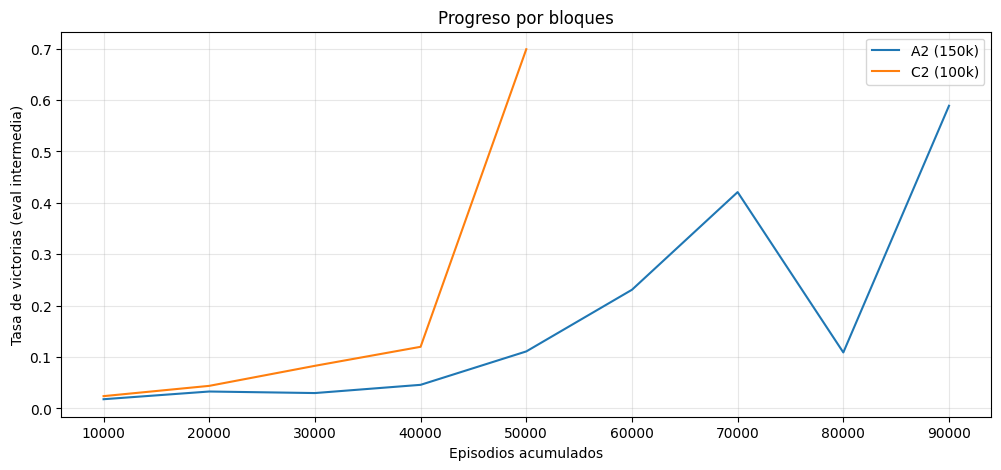

In [73]:
# 🏗️ Corrida larga: A2 (150k) y C2 (100k) con max_pasos=250

print("\n⏳ Iniciando corridas largas (esto puede tardar ~1 min)...")
# print(f"A2 larg0: episodios=150000, bloque=10000, max_pasos=250")
# print(f"C2 largo: episodios=100000, bloque=10000, max_pasos=250")

ag_A2_L, res_A2_L, prog_A2_L, t_A2_L, pol_A2_L = entrenar_en_bloques(
    cfg_A2, episodios_total=90000, tam_bloque=10000, max_pasos=99, eval_intermedia=1000
)

ag_C2_L, res_C2_L, prog_C2_L, t_C2_L, pol_C2_L = entrenar_en_bloques(
    cfg_C2, episodios_total=50000, tam_bloque=10000, max_pasos=99, eval_intermedia=1000
)

print("\n✅ Resultados finales corridas largas (eval=1000):")
print(f"A2(150k) | tasa={res_A2_L['tasa_victorias']:.1%} | recompensa={res_A2_L['recompensa_promedio']:.3f} | tiempo={t_A2_L:.1f}s")
print(f"C2(100k) | tasa={res_C2_L['tasa_victorias']:.1%} | recompensa={res_C2_L['recompensa_promedio']:.3f} | tiempo={t_C2_L:.1f}s")

print("\n🧭 Política aprendida (A2 150k):\n", pol_A2_L)
print("\n🧭 Política aprendida (C2 100k):\n", pol_C2_L)

# Curvas de progreso
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(prog_A2_L['bloque']*10000, prog_A2_L['tasa_victorias'], label='A2 (150k)')
plt.plot(prog_C2_L['bloque']*10000, prog_C2_L['tasa_victorias'], label='C2 (100k)')
plt.xlabel('Episodios acumulados')
plt.ylabel('Tasa de victorias (eval intermedia)')
plt.title('Progreso por bloques')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [64]:
# 🛡️ Entrenamiento avanzado con checkpoint, alpha-decay y evaluación greedy

import copy

def evaluar_greedy(agente, env, num_episodios=1000, max_pasos=250):
    eps_backup = agente.epsilon
    agente.epsilon = 0.0  # política puramente codiciosa
    resultados = evaluar_agente(agente, env, num_episodios=num_episodios)
    agente.epsilon = eps_backup
    return resultados


def entrenar_con_checkpoint(cfg, episodios_total=100000, tam_bloque=10000, max_pasos=250,
                            eval_intermedia=500, epsilon_min=0.01, alpha_decay=None):
    env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
    agente = AgenteQLearning(
        observation_space_n=env.observation_space.n,
        action_space_n=env.action_space.n,
        alpha=cfg['alpha'],
        gamma=cfg['gamma'],
        epsilon=1.0,
        epsilon_decay=cfg['epsilon_decay']
    )

    mejor_tasa = -1.0
    mejor_q = None
    progreso = []

    bloques = episodios_total // tam_bloque
    for b in range(bloques):
        # Entrenamiento episodio a episodio para controlar epsilon/alpha
        for _ in range(tam_bloque):
            estado, _ = env.reset()
            for _paso in range(max_pasos):
                accion = agente.elegir_accion(estado)
                siguiente_estado, recompensa, terminado, truncado, _info = env.step(accion)
                agente.aprender(estado, accion, recompensa, siguiente_estado, terminado or truncado)
                estado = siguiente_estado
                if terminado or truncado:
                    break
            # Decaimientos controlados
            agente.epsilon = max(epsilon_min, agente.epsilon - agente.epsilon_decay)
            if alpha_decay is not None:
                agente.alpha = max(0.05, agente.alpha * alpha_decay)
        
        # Evaluación intermedia (greedy) y checkpoint
        res_mid = evaluar_greedy(agente, env, num_episodios=eval_intermedia, max_pasos=max_pasos)
        tasa_mid = res_mid['tasa_victorias']
        progreso.append({'bloque': b+1, 'tasa': tasa_mid, 'epsilon': agente.epsilon, 'alpha': agente.alpha})
        print(f"Bloque {b+1}/{bloques} | tasa_greedy={tasa_mid:.1%} | ε={agente.epsilon:.3f} | α={agente.alpha:.3f}")

        if tasa_mid > mejor_tasa:
            mejor_tasa = tasa_mid
            mejor_q = copy.deepcopy(agente.qtable)

    # Restaurar mejor Q-table y evaluación final
    if mejor_q is not None:
        agente.qtable = mejor_q

    res_final = evaluar_greedy(agente, env, num_episodios=1000, max_pasos=max_pasos)
    env.close()
    return agente, res_final, pd.DataFrame(progreso)

print("\n🔧 Entrenador avanzado cargado: checkpoint + alpha_decay + evaluación greedy")


🔧 Entrenador avanzado cargado: checkpoint + alpha_decay + evaluación greedy


Probando C2 con entrenador avanzado | α0=0.6, γ=0.995, ε_decay=0.000020
Bloque 1/8 | tasa_greedy=43.6% | ε=0.901 | α=0.571
Bloque 1/8 | tasa_greedy=43.6% | ε=0.901 | α=0.571
Bloque 2/8 | tasa_greedy=17.0% | ε=0.802 | α=0.543
Bloque 2/8 | tasa_greedy=17.0% | ε=0.802 | α=0.543
Bloque 3/8 | tasa_greedy=40.4% | ε=0.703 | α=0.516
Bloque 3/8 | tasa_greedy=40.4% | ε=0.703 | α=0.516
Bloque 4/8 | tasa_greedy=47.6% | ε=0.604 | α=0.491
Bloque 4/8 | tasa_greedy=47.6% | ε=0.604 | α=0.491
Bloque 5/8 | tasa_greedy=61.6% | ε=0.505 | α=0.467
Bloque 5/8 | tasa_greedy=61.6% | ε=0.505 | α=0.467
Bloque 6/8 | tasa_greedy=21.0% | ε=0.406 | α=0.444
Bloque 6/8 | tasa_greedy=21.0% | ε=0.406 | α=0.444
Bloque 7/8 | tasa_greedy=10.4% | ε=0.307 | α=0.423
Bloque 7/8 | tasa_greedy=10.4% | ε=0.307 | α=0.423
Bloque 8/8 | tasa_greedy=74.0% | ε=0.208 | α=0.402
Bloque 8/8 | tasa_greedy=74.0% | ε=0.208 | α=0.402

📊 Resultado final (greedy, 1000 evals):
{'recompensas_totales': [0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0

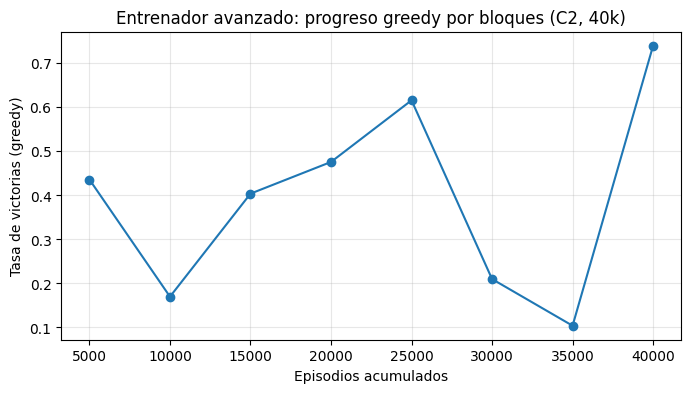

In [65]:
# 🧪 Prueba corta con entrenador avanzado (C2, 40k episodios)

cfg = seleccionar_config('C2:')
print(f"Probando C2 con entrenador avanzado | α0={cfg['alpha']}, γ={cfg['gamma']}, ε_decay={cfg['epsilon_decay']:.6f}")

# Decaimiento suave de α (multiplicativo) y checkpoint
tagente_adv, res_final_adv, prog_adv = entrenar_con_checkpoint(
    cfg, episodios_total=40000, tam_bloque=5000, max_pasos=250,
    eval_intermedia=500, epsilon_min=0.01, alpha_decay=0.99999
)

print("\n📊 Resultado final (greedy, 1000 evals):")
print(res_final_adv)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(prog_adv['bloque']*5000, prog_adv['tasa'], marker='o')
plt.title('Entrenador avanzado: progreso greedy por bloques (C2, 40k)')
plt.xlabel('Episodios acumulados')
plt.ylabel('Tasa de victorias (greedy)')
plt.grid(True, alpha=0.3)
plt.show()

Lanzando entrenador avanzado 100k | α0=0.6, γ=0.995, ε_decay=0.000020
Bloque 1/10 | tasa_greedy=30.3% | ε=0.802 | α=0.571
Bloque 1/10 | tasa_greedy=30.3% | ε=0.802 | α=0.571
Bloque 2/10 | tasa_greedy=54.3% | ε=0.604 | α=0.543
Bloque 2/10 | tasa_greedy=54.3% | ε=0.604 | α=0.543
Bloque 3/10 | tasa_greedy=0.0% | ε=0.406 | α=0.516
Bloque 3/10 | tasa_greedy=0.0% | ε=0.406 | α=0.516
Bloque 4/10 | tasa_greedy=0.0% | ε=0.208 | α=0.491
Bloque 4/10 | tasa_greedy=0.0% | ε=0.208 | α=0.491
Bloque 5/10 | tasa_greedy=73.3% | ε=0.010 | α=0.467
Bloque 5/10 | tasa_greedy=73.3% | ε=0.010 | α=0.467
Bloque 6/10 | tasa_greedy=77.3% | ε=0.010 | α=0.444
Bloque 6/10 | tasa_greedy=77.3% | ε=0.010 | α=0.444
Bloque 7/10 | tasa_greedy=65.0% | ε=0.010 | α=0.423
Bloque 7/10 | tasa_greedy=65.0% | ε=0.010 | α=0.423
Bloque 8/10 | tasa_greedy=66.8% | ε=0.010 | α=0.402
Bloque 8/10 | tasa_greedy=66.8% | ε=0.010 | α=0.402
Bloque 9/10 | tasa_greedy=0.0% | ε=0.010 | α=0.383
Bloque 9/10 | tasa_greedy=0.0% | ε=0.010 | α=0.383


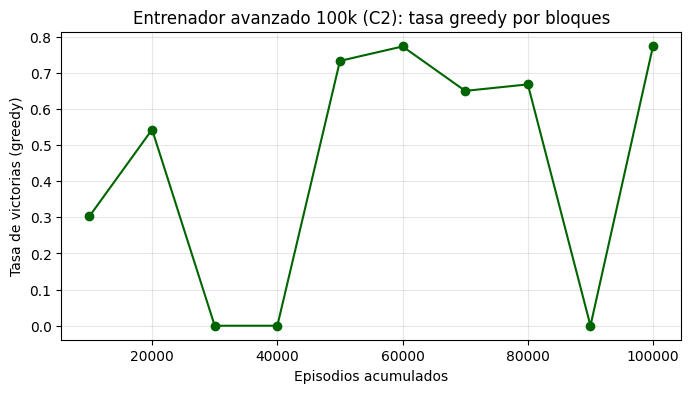


🧭 Política final (greedy, con checkpoint):
[['←' '↑' '↑' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]


In [71]:
# 🚀 Entrenador avanzado: corrida objetivo 100k (C2) para estabilizar >60%

cfg_target = seleccionar_config('C2:')
print(f"Lanzando entrenador avanzado 100k | α0={cfg_target['alpha']}, γ={cfg_target['gamma']}, ε_decay={cfg_target['epsilon_decay']:.6f}")

agent_100k, res_100k, prog_100k = entrenar_con_checkpoint(
    cfg_target, episodios_total=100000, tam_bloque=10000, max_pasos=99,
    eval_intermedia=1000, epsilon_min=0.01, alpha_decay=0.999995
)

print("\n🎯 Resultado final greedy (1000 evals):")
print(f"tasa={res_100k['tasa_victorias']:.1%} | recompensa={res_100k['recompensa_promedio']:.3f} | desv={res_100k['desv_estandar']:.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(prog_100k['bloque']*10000, prog_100k['tasa'], marker='o', color='darkgreen')
plt.title('Entrenador avanzado 100k (C2): tasa greedy por bloques')
plt.xlabel('Episodios acumulados')
plt.ylabel('Tasa de victorias (greedy)')
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar política final
acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
pol_final = np.array([acciones_mapa[int(np.argmax(agent_100k.qtable[s, :]))] for s in range(agent_100k.qtable.shape[0])]).reshape(4,4)
print("\n🧭 Política final (greedy, con checkpoint):")
print(pol_final)

In [74]:
# 💾 Guardar Q-table/política y validación multi-seed (3×30k)

import os, random

# 1) Guardar el mejor modelo obtenido (de agent_100k)
artifact_dir = '.'
q_path = os.path.join(artifact_dir, 'qtable_slippery_C2_100k.npy')
np.save(q_path, agent_100k.qtable)
print(f"✅ Q-table guardada en: {q_path}")

# Guardar política como texto (UTF-8 para flechas)
acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
pol_chars = np.array([acciones_mapa[int(np.argmax(agent_100k.qtable[s, :]))] for s in range(agent_100k.qtable.shape[0])]).reshape(4,4)
pol_txt_path = os.path.join(artifact_dir, 'policy_slippery_C2_100k.txt')
with open(pol_txt_path, 'w', encoding='utf-8') as f:
    for row in pol_chars:
        f.write(' '.join(row) + '\n')
print(f"✅ Política guardada en: {pol_txt_path}")

# 2) Funciones para cargar y evaluar

def cargar_qtable(path):
    return np.load(path)

def evaluar_politica_qtable(qtable, num_episodios=1000, max_pasos=250):
    env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
    # Agente dummy con Q-table fija y epsilon=0
    agente = AgenteQLearning(env.observation_space.n, env.action_space.n, alpha=0.0, gamma=1.0, epsilon=0.0, epsilon_decay=0.0)
    agente.qtable = qtable.copy()
    res = evaluar_agente(agente, env, num_episodios=num_episodios)
    env.close()
    return res

res_chk = evaluar_politica_qtable(cargar_qtable(q_path), num_episodios=1000)
print(f"📦 Checkpoint evaluado (greedy): tasa={res_chk['tasa_victorias']:.1%}")

# 3) Validación multi-seed: 3 semillas × 30k episodios
seeds = [0, 1, 2]
print("\n🧪 Validación multi-seed (3×30k) con entrenador avanzado...")

resultados_seeds = []
for seed in seeds:
    np.random.seed(seed); random.seed(seed)
    cfg = seleccionar_config('C2:')
    agent_s, res_s, prog_s = entrenar_con_checkpoint(
        cfg, episodios_total=30000, tam_bloque=5000, max_pasos=250,
        eval_intermedia=500, epsilon_min=0.01, alpha_decay=0.999995
    )
    resultados_seeds.append({'seed': seed, 'tasa_final': res_s['tasa_victorias'], 'recompensa': res_s['recompensa_promedio']})
    print(f"   seed={seed} → tasa_final={res_s['tasa_victorias']:.1%}")

import pandas as pd
res_df = pd.DataFrame(resultados_seeds)
print("\n📊 Resumen multi-seed:")
print(res_df.to_string(index=False))
print(f"\nPromedio tasa_final: {res_df['tasa_final'].mean():.1%} | Desv: {res_df['tasa_final'].std():.1%}")

✅ Q-table guardada en: .\qtable_slippery_C2_100k.npy
✅ Política guardada en: .\policy_slippery_C2_100k.txt
📦 Checkpoint evaluado (greedy): tasa=73.0%

🧪 Validación multi-seed (3×30k) con entrenador avanzado...
📦 Checkpoint evaluado (greedy): tasa=73.0%

🧪 Validación multi-seed (3×30k) con entrenador avanzado...
Bloque 1/6 | tasa_greedy=49.8% | ε=0.901 | α=0.585
Bloque 1/6 | tasa_greedy=49.8% | ε=0.901 | α=0.585
Bloque 2/6 | tasa_greedy=77.0% | ε=0.802 | α=0.571
Bloque 2/6 | tasa_greedy=77.0% | ε=0.802 | α=0.571
Bloque 3/6 | tasa_greedy=73.6% | ε=0.703 | α=0.557
Bloque 3/6 | tasa_greedy=73.6% | ε=0.703 | α=0.557
Bloque 4/6 | tasa_greedy=54.6% | ε=0.604 | α=0.543
Bloque 4/6 | tasa_greedy=54.6% | ε=0.604 | α=0.543
Bloque 5/6 | tasa_greedy=56.6% | ε=0.505 | α=0.529
Bloque 5/6 | tasa_greedy=56.6% | ε=0.505 | α=0.529
Bloque 6/6 | tasa_greedy=72.6% | ε=0.406 | α=0.516
Bloque 6/6 | tasa_greedy=72.6% | ε=0.406 | α=0.516
   seed=0 → tasa_final=74.3%
   seed=0 → tasa_final=74.3%
Bloque 1/6 | tasa


Probando entrenador α_n=1/visitas(s,a) | γ=0.995, ε_decay=0.000020
Bloque 1/6 | tasa_greedy=43.6% | ε=0.802 | α=1/visitas
Bloque 1/6 | tasa_greedy=43.6% | ε=0.802 | α=1/visitas
Bloque 2/6 | tasa_greedy=43.6% | ε=0.604 | α=1/visitas
Bloque 2/6 | tasa_greedy=43.6% | ε=0.604 | α=1/visitas
Bloque 3/6 | tasa_greedy=45.3% | ε=0.406 | α=1/visitas
Bloque 3/6 | tasa_greedy=45.3% | ε=0.406 | α=1/visitas
Bloque 4/6 | tasa_greedy=45.1% | ε=0.208 | α=1/visitas
Bloque 4/6 | tasa_greedy=45.1% | ε=0.208 | α=1/visitas
Bloque 5/6 | tasa_greedy=46.8% | ε=0.010 | α=1/visitas
Bloque 5/6 | tasa_greedy=46.8% | ε=0.010 | α=1/visitas
Bloque 6/6 | tasa_greedy=43.6% | ε=0.010 | α=1/visitas

📊 Resultado final (greedy, 1000 evals) con α=1/visitas:
{'recompensas_totales': [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,

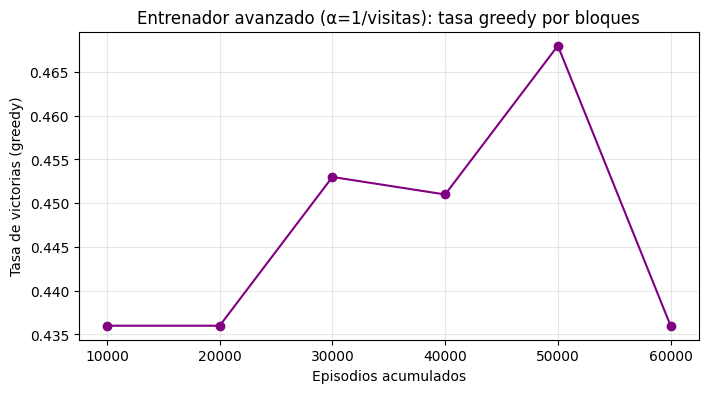

In [118]:
# 🧮 Entrenador avanzado con α(s,a)=1/visitas(s,a) + checkpoint y evaluación greedy
import numpy as np
import gymnasium as gym
import pandas as pd
import copy


def entrenar_con_checkpoint_alpha_visitas(cfg, episodios_total=100000, tam_bloque=10000, max_pasos=250,
                                          eval_intermedia=500, epsilon_min=0.01):
    """
    Variante del entrenador avanzado que usa tasa de aprendizaje por-par (s,a):
      α_n(s,a) = 1 / visitas(s,a)
    - Política epsilon-greedy con ε lineal decreciente (como cfg['epsilon_decay']).
    - Checkpoint del mejor Q-table según evaluación greedy intermedia.
    - Sin alpha_decay global: el aprendizaje depende EXCLUSIVAMENTE de visitas(s,a).
    """
    env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
    agente = AgenteQLearning(
        observation_space_n=env.observation_space.n,
        action_space_n=env.action_space.n,
        alpha=cfg['alpha'],   # No se usa en la actualización, pero mantenemos compatibilidad
        gamma=cfg['gamma'],
        epsilon=1.0,
        epsilon_decay=cfg['epsilon_decay']
    )

    # Contador de visitas por (s,a) para α_n(s,a) = 1/n
    visitas = np.zeros_like(agente.qtable, dtype=np.int64)

    mejor_tasa = -1.0
    mejor_q = None
    progreso = []

    bloques = max(1, episodios_total // tam_bloque)
    for b in range(bloques):
        for _ in range(tam_bloque):
            estado, _ = env.reset()
            for _paso in range(max_pasos):
                accion = agente.elegir_accion(estado)
                siguiente_estado, recompensa, terminado, truncado, _info = env.step(accion)

                # α_n(s,a) = 1 / visitas(s,a)
                visitas[estado, accion] += 1
                alpha_sa = 1.0 / visitas[estado, accion]

                # Objetivo TD (Q-Learning)
                if terminado or truncado:
                    td_target = recompensa
                else:
                    td_target = recompensa + agente.gamma * np.max(agente.qtable[siguiente_estado, :])

                # Actualización tabular con α(s,a) específico
                q_old = agente.qtable[estado, accion]
                agente.qtable[estado, accion] = (1.0 - alpha_sa) * q_old + alpha_sa * td_target

                estado = siguiente_estado
                if terminado or truncado:
                    break

            # Decaimiento de epsilon por episodio (lineal como antes)
            agente.epsilon = max(epsilon_min, agente.epsilon - agente.epsilon_decay)

        # Evaluación intermedia (greedy) y checkpoint
        res_mid = evaluar_greedy(agente, env, num_episodios=eval_intermedia, max_pasos=max_pasos)
        tasa_mid = res_mid['tasa_victorias']
        progreso.append({'bloque': b + 1, 'tasa': tasa_mid, 'epsilon': agente.epsilon, 'alpha': np.nan})
        print(f"Bloque {b+1}/{bloques} | tasa_greedy={tasa_mid:.1%} | ε={agente.epsilon:.3f} | α=1/visitas")

        if tasa_mid > mejor_tasa:
            mejor_tasa = tasa_mid
            mejor_q = copy.deepcopy(agente.qtable)

    # Restaurar mejor Q-table y evaluación final
    if mejor_q is not None:
        agente.qtable = mejor_q

    res_final = evaluar_greedy(agente, env, num_episodios=1000, max_pasos=max_pasos)
    env.close()
    return agente, res_final, pd.DataFrame(progreso)


# ▶️ Prueba: usar la config C2 con α(s,a)=1/visitas(s,a)
cfg_vis = seleccionar_config('C2:')
print(f"\nProbando entrenador α_n=1/visitas(s,a) | γ={cfg_vis['gamma']}, ε_decay={cfg_vis['epsilon_decay']:.6f}")

agent_vis, res_vis, prog_vis = entrenar_con_checkpoint_alpha_visitas(
    cfg_vis, episodios_total=60000, tam_bloque=10000, max_pasos=99,
    eval_intermedia=1000, epsilon_min=0.01
)

print("\n📊 Resultado final (greedy, 1000 evals) con α=1/visitas:")
print(res_vis)

# Política aprendida
acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
policy_grid = np.array([acciones_mapa[int(np.argmax(agent_vis.qtable[s, :]))] for s in range(agent_vis.qtable.shape[0])]).reshape(4, 4)
print("\n🧭 Política final (α=1/visitas):")
print(policy_grid)

# Curva de progreso
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(prog_vis['bloque']*10000, prog_vis['tasa'], marker='o', color='purple')
plt.title('Entrenador avanzado (α=1/visitas): tasa greedy por bloques')
plt.xlabel('Episodios acumulados')
plt.ylabel('Tasa de victorias (greedy)')
plt.grid(True, alpha=0.3)
plt.show()

In [119]:
# 🏁 Evaluación de la política aprendida sobre FrozenLake real (slippery)
import gymnasium as gym
import numpy as np

# Usar la Q-table final del agente entrenado (por ejemplo, agent_100k)
qtable_final = agent_100k.qtable

# Construir la política greedy (acción óptima por estado)
politica_greedy = np.argmax(qtable_final, axis=1)
print("Política aprendida (acción óptima por estado):")
print(politica_greedy.reshape(4,4))

# Evaluar la política greedy en el entorno real
num_episodios = 1000
exitos = 0
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
for ep in range(num_episodios):
    estado, _ = env.reset()
    for paso in range(250):
        accion = politica_greedy[estado]
        estado, recompensa, terminado, truncado, _ = env.step(accion)
        if terminado or truncado:
            if recompensa > 0:
                exitos += 1
            break
env.close()

print(f"\nTasa de aciertos global (victorias greedy): {exitos/num_episodios:.1%} ({exitos} de {num_episodios})")
print("La tasa de aciertos indica el porcentaje de episodios en que la política greedy llega al objetivo en FrozenLake.")

Política aprendida (acción óptima por estado):
[[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]

Tasa de aciertos global (victorias greedy): 73.7% (737 de 1000)
La tasa de aciertos indica el porcentaje de episodios en que la política greedy llega al objetivo en FrozenLake.


In [124]:
# 🏁 Evaluación de la política aprendida (α = 1/visitas) sobre FrozenLake real (slippery)
import gymnasium as gym
import numpy as np

# Usar la Q-table final del agente entrenado con α = 1/visitas (agent_vis)
qtable_vis = agent_vis.qtable

# Construir la política greedy (acción óptima por estado)
politica_greedy_vis = np.argmax(qtable_vis, axis=1)
print("Política aprendida (acción óptima por estado, α=1/visitas):")
print(politica_greedy_vis.reshape(4,4))

# Evaluar la política greedy en el entorno real
num_episodios = 1000
exitos = 0
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
for ep in range(num_episodios):
    estado, _ = env.reset()
    for paso in range(250):
        accion = politica_greedy_vis[estado]
        estado, recompensa, terminado, truncado, _ = env.step(accion)
        if terminado or truncado:
            if recompensa > 0:
                exitos += 1
            break
env.close()

print(f"\nTasa de aciertos global (victorias greedy, α=1/visitas): {exitos/num_episodios:.1%} ({exitos} de {num_episodios})")
print("La tasa de aciertos indica el porcentaje de episodios en que la política greedy llega al objetivo en FrozenLake usando α=1/visitas.")

Política aprendida (acción óptima por estado, α=1/visitas):
[[2 3 2 3]
 [0 0 2 0]
 [3 1 0 0]
 [0 2 1 0]]

Tasa de aciertos global (victorias greedy, α=1/visitas): 42.7% (427 de 1000)
La tasa de aciertos indica el porcentaje de episodios en que la política greedy llega al objetivo en FrozenLake usando α=1/visitas.


🧪 Comparación α=1/visitas con múltiples configuraciones

🔄 Probando A2_vis: γ=0.995, 50% expl...
   Parámetros: α_orig=0.7, γ=0.995, ε_decay=0.000013
Bloque 1/10 | tasa_greedy=45.9% | ε=0.868 | α=1/visitas
Bloque 1/10 | tasa_greedy=45.9% | ε=0.868 | α=1/visitas
Bloque 2/10 | tasa_greedy=43.7% | ε=0.736 | α=1/visitas
Bloque 2/10 | tasa_greedy=43.7% | ε=0.736 | α=1/visitas
Bloque 3/10 | tasa_greedy=43.4% | ε=0.604 | α=1/visitas
Bloque 3/10 | tasa_greedy=43.4% | ε=0.604 | α=1/visitas
Bloque 4/10 | tasa_greedy=44.2% | ε=0.472 | α=1/visitas
Bloque 4/10 | tasa_greedy=44.2% | ε=0.472 | α=1/visitas
Bloque 5/10 | tasa_greedy=43.6% | ε=0.340 | α=1/visitas
Bloque 5/10 | tasa_greedy=43.6% | ε=0.340 | α=1/visitas
Bloque 6/10 | tasa_greedy=45.6% | ε=0.208 | α=1/visitas
Bloque 6/10 | tasa_greedy=45.6% | ε=0.208 | α=1/visitas
Bloque 7/10 | tasa_greedy=44.8% | ε=0.076 | α=1/visitas
Bloque 7/10 | tasa_greedy=44.8% | ε=0.076 | α=1/visitas
Bloque 8/10 | tasa_greedy=45.2% | ε=0.010 | α=1/visitas
Bloque 8/1

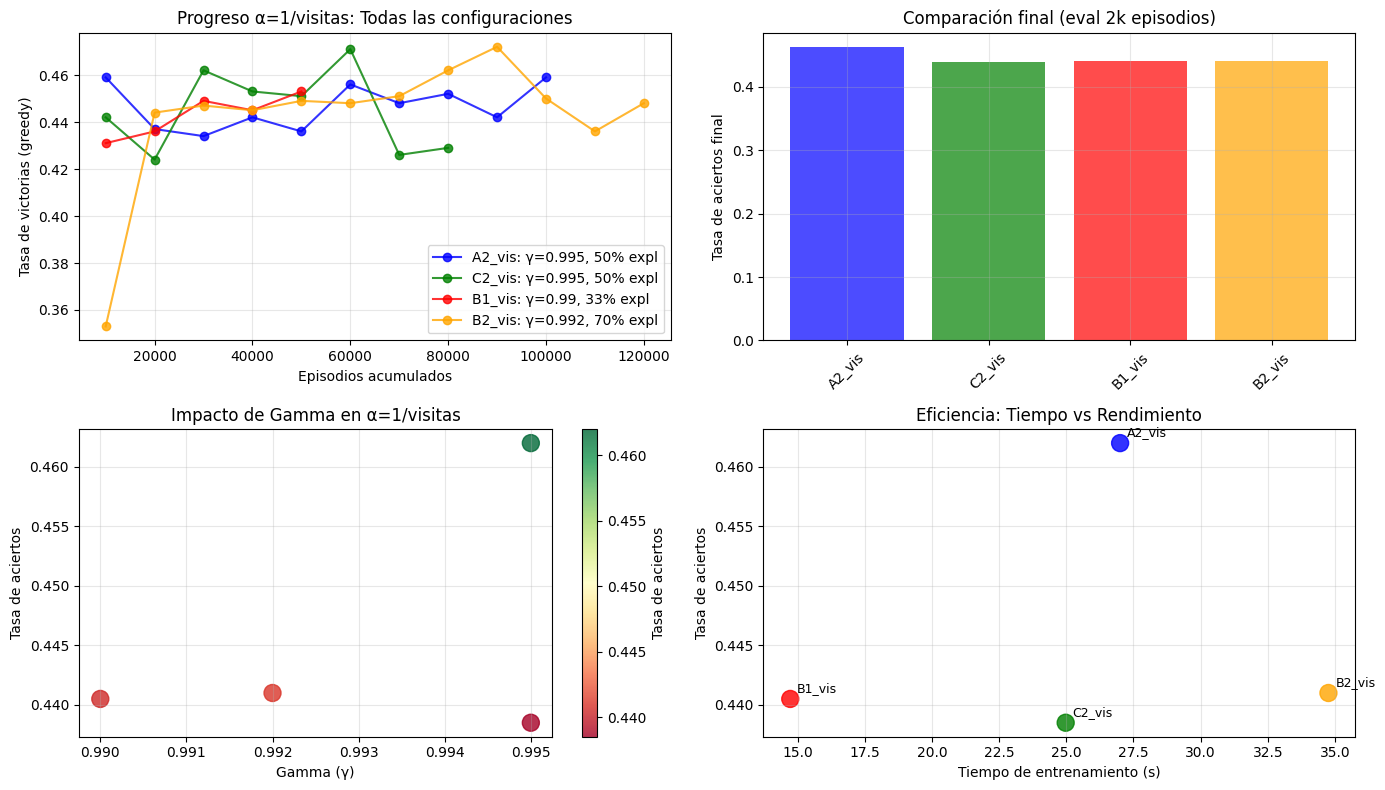


📋 TABLA DETALLADA:
----------------------------------------------------------------------------------------------------
                   nombre  gamma  alpha_original  epsilon_decay  tasa_final  tasa_extenso  tiempo_s
A2_vis: γ=0.995, 50% expl  0.995            0.70            0.0       0.447        0.4620   27.0027
B2_vis: γ=0.992, 70% expl  0.992            0.75            0.0       0.449        0.4410   34.7561
 B1_vis: γ=0.99, 33% expl  0.990            0.80            0.0       0.459        0.4405   14.7267
C2_vis: γ=0.995, 50% expl  0.995            0.60            0.0       0.425        0.4385   24.9770

💡 CONCLUSIONES:
- Mejor configuración α=1/visitas: A2_vis: γ=0.995, 50% expl
- Rango de rendimiento: 43.9% - 46.2%
- Tiempo promedio: 25.4s


In [127]:
# 🧮 Comparación múltiple: α=1/visitas con diferentes configuraciones

import time
import matplotlib.pyplot as plt

# Configuraciones a probar (con %exploracion razonable: 33-70%)
configs_comparar = [
    {
        'nombre': 'A2_vis: γ=0.995, 50% expl',
        'config': seleccionar_config('A2:'),  # α=0.7, γ=0.995, 50% expl
        'episodios': 100000, 'color': 'blue'
    },
    {
        'nombre': 'C2_vis: γ=0.995, 50% expl', 
        'config': seleccionar_config('C2:'),  # α=0.6, γ=0.995, 50% expl
        'episodios': 80000, 'color': 'green'
    },
    {
        'nombre': 'B1_vis: γ=0.99, 33% expl',
        'config': seleccionar_config('B1:'),  # α=0.8, γ=0.99, 33% expl
        'episodios': 50000, 'color': 'red'
    },
    {
        'nombre': 'B2_vis: γ=0.992, 70% expl',
        'config': seleccionar_config('B2:'),  # α=0.75, γ=0.992, 70% expl
        'episodios': 120000, 'color': 'orange'
    }
]

print("🧪 Comparación α=1/visitas con múltiples configuraciones")
print("="*70)

resultados_comparacion = []
progresos_comparacion = []

for i, cfg_test in enumerate(configs_comparar):
    print(f"\n🔄 Probando {cfg_test['nombre']}...")
    cfg = cfg_test['config']
    print(f"   Parámetros: α_orig={cfg['alpha']}, γ={cfg['gamma']}, ε_decay={cfg['epsilon_decay']:.6f}")
    
    t0 = time.time()
    agent_test, res_test, prog_test = entrenar_con_checkpoint_alpha_visitas(
        cfg, 
        episodios_total=cfg_test['episodios'], 
        tam_bloque=10000, 
        max_pasos=99,
        eval_intermedia=1000, 
        epsilon_min=0.01
    )
    tiempo_total = time.time() - t0
    
    # Política aprendida
    acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    policy_test = np.array([acciones_mapa[int(np.argmax(agent_test.qtable[s, :]))] for s in range(agent_test.qtable.shape[0])]).reshape(4, 4)
    
    # Evaluación adicional con más episodios para métricas robustas
    print("   📊 Evaluación adicional (2000 episodios)...")
    env_eval = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
    agent_dummy = AgenteQLearning(env_eval.observation_space.n, env_eval.action_space.n, alpha=0.0, gamma=1.0, epsilon=0.0, epsilon_decay=0.0)
    agent_dummy.qtable = agent_test.qtable.copy()
    res_extenso = evaluar_agente(agent_dummy, env_eval, num_episodios=2000)
    env_eval.close()
    
    # Guardar resultados
    resultado = {
        'nombre': cfg_test['nombre'],
        'gamma': cfg['gamma'],
        'alpha_original': cfg['alpha'],
        'epsilon_decay': cfg['epsilon_decay'],
        'episodios': cfg_test['episodios'],
        'tasa_final': res_test['tasa_victorias'],
        'tasa_extenso': res_extenso['tasa_victorias'],
        'recompensa_promedio': res_extenso['recompensa_promedio'],
        'desv_std': res_extenso['desv_estandar'],
        'tiempo_s': tiempo_total,
        'politica': policy_test,
        'color': cfg_test['color']
    }
    
    resultados_comparacion.append(resultado)
    
    # Agregar información de configuración al progreso para el gráfico
    prog_test['config_nombre'] = cfg_test['nombre']
    prog_test['color'] = cfg_test['color']
    prog_test['episodios_acum'] = prog_test['bloque'] * 10000
    progresos_comparacion.append(prog_test)
    
    print(f"   ✅ Tasa final (greedy): {res_test['tasa_victorias']:.1%}")
    print(f"   📈 Tasa extenso (2k evals): {res_extenso['tasa_victorias']:.1%}")
    print(f"   ⏱️  Tiempo: {tiempo_total:.1f}s")
    print(f"   🧭 Política:\n{policy_test}")

# Resumen de resultados
print("\n" + "="*70)
print("📊 RESUMEN COMPARATIVO (α=1/visitas)")
print("="*70)

df_comparacion = pd.DataFrame(resultados_comparacion)
df_ordenado = df_comparacion.sort_values('tasa_extenso', ascending=False)

print("\n🏆 Ranking por tasa de aciertos (evaluación extenso):")
for i, (_, row) in enumerate(df_ordenado.iterrows()):
    print(f"{i+1}. {row['nombre']}: {row['tasa_extenso']:.1%} "
          f"(γ={row['gamma']}, α_orig={row['alpha_original']}, ε_decay={row['epsilon_decay']:.6f})")

# Estadísticas
mejor_config = df_ordenado.iloc[0]
print(f"\n🥇 Mejor configuración: {mejor_config['nombre']}")
print(f"   📊 Tasa de aciertos: {mejor_config['tasa_extenso']:.1%}")
print(f"   📈 Recompensa promedio: {mejor_config['recompensa_promedio']:.3f}")
print(f"   📉 Desviación estándar: {mejor_config['desv_std']:.3f}")
print(f"   ⏱️  Tiempo: {mejor_config['tiempo_s']:.1f}s")

# Gráfico conjunto de progreso
plt.figure(figsize=(14, 8))

# Subplot 1: Progreso por episodios
plt.subplot(2, 2, 1)
for prog in progresos_comparacion:
    plt.plot(prog['episodios_acum'], prog['tasa'], 
             marker='o', label=prog['config_nombre'].iloc[0], 
             color=prog['color'].iloc[0], alpha=0.8)

plt.xlabel('Episodios acumulados')
plt.ylabel('Tasa de victorias (greedy)')
plt.title('Progreso α=1/visitas: Todas las configuraciones')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Comparación final
plt.subplot(2, 2, 2)
nombres_cortos = [nombre.split(':')[0] for nombre in df_comparacion['nombre']]
plt.bar(nombres_cortos, df_comparacion['tasa_extenso'], 
        color=df_comparacion['color'], alpha=0.7)
plt.ylabel('Tasa de aciertos final')
plt.title('Comparación final (eval 2k episodios)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Subplot 3: Gamma vs Rendimiento
plt.subplot(2, 2, 3)
plt.scatter(df_comparacion['gamma'], df_comparacion['tasa_extenso'], 
           c=df_comparacion['tasa_extenso'], s=150, cmap='RdYlGn', alpha=0.8)
plt.xlabel('Gamma (γ)')
plt.ylabel('Tasa de aciertos')
plt.title('Impacto de Gamma en α=1/visitas')
plt.colorbar(label='Tasa de aciertos')
plt.grid(True, alpha=0.3)

# Subplot 4: Tiempo vs Rendimiento
plt.subplot(2, 2, 4)
plt.scatter(df_comparacion['tiempo_s'], df_comparacion['tasa_extenso'], 
           c=df_comparacion['color'], s=150, alpha=0.8)
for i, row in df_comparacion.iterrows():
    plt.annotate(row['nombre'].split(':')[0], 
                (row['tiempo_s'], row['tasa_extenso']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.xlabel('Tiempo de entrenamiento (s)')
plt.ylabel('Tasa de aciertos')
plt.title('Eficiencia: Tiempo vs Rendimiento')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla detallada
print(f"\n📋 TABLA DETALLADA:")
print("-"*100)
tabla_mostrar = df_ordenado[['nombre', 'gamma', 'alpha_original', 'epsilon_decay', 
                           'tasa_final', 'tasa_extenso', 'tiempo_s']].round(4)
print(tabla_mostrar.to_string(index=False))

print(f"\n💡 CONCLUSIONES:")
print(f"- Mejor configuración α=1/visitas: {mejor_config['nombre']}")
print(f"- Rango de rendimiento: {df_comparacion['tasa_extenso'].min():.1%} - {df_comparacion['tasa_extenso'].max():.1%}")
print(f"- Tiempo promedio: {df_comparacion['tiempo_s'].mean():.1f}s")

🎯 Estrategias para mejorar α=1/visitas y superar 50%

🚀 Probando configuraciones optimizadas...

🧪 Configuración 1: Ultra_A2: γ=0.998, exploración extendida
   γ=0.998, α_offset=15, α_min=0.04
Entrenando 80000 episodios en 8 bloques de 10000
Bloque 1/8 | tasa_greedy=65.1% | ε=0.8894 | α_prom=0.0400
Bloque 1/8 | tasa_greedy=65.1% | ε=0.8894 | α_prom=0.0400
Bloque 2/8 | tasa_greedy=76.9% | ε=0.7789 | α_prom=0.0400
Bloque 2/8 | tasa_greedy=76.9% | ε=0.7789 | α_prom=0.0400
Bloque 3/8 | tasa_greedy=71.5% | ε=0.6683 | α_prom=0.0400
Bloque 3/8 | tasa_greedy=71.5% | ε=0.6683 | α_prom=0.0400
Bloque 4/8 | tasa_greedy=72.6% | ε=0.5578 | α_prom=0.0400
Bloque 4/8 | tasa_greedy=72.6% | ε=0.5578 | α_prom=0.0400
Bloque 5/8 | tasa_greedy=70.4% | ε=0.4472 | α_prom=0.0400
Bloque 5/8 | tasa_greedy=70.4% | ε=0.4472 | α_prom=0.0400
Bloque 6/8 | tasa_greedy=66.6% | ε=0.3367 | α_prom=0.0400
Bloque 6/8 | tasa_greedy=66.6% | ε=0.3367 | α_prom=0.0400
Bloque 7/8 | tasa_greedy=72.1% | ε=0.2261 | α_prom=0.0400
Bloq

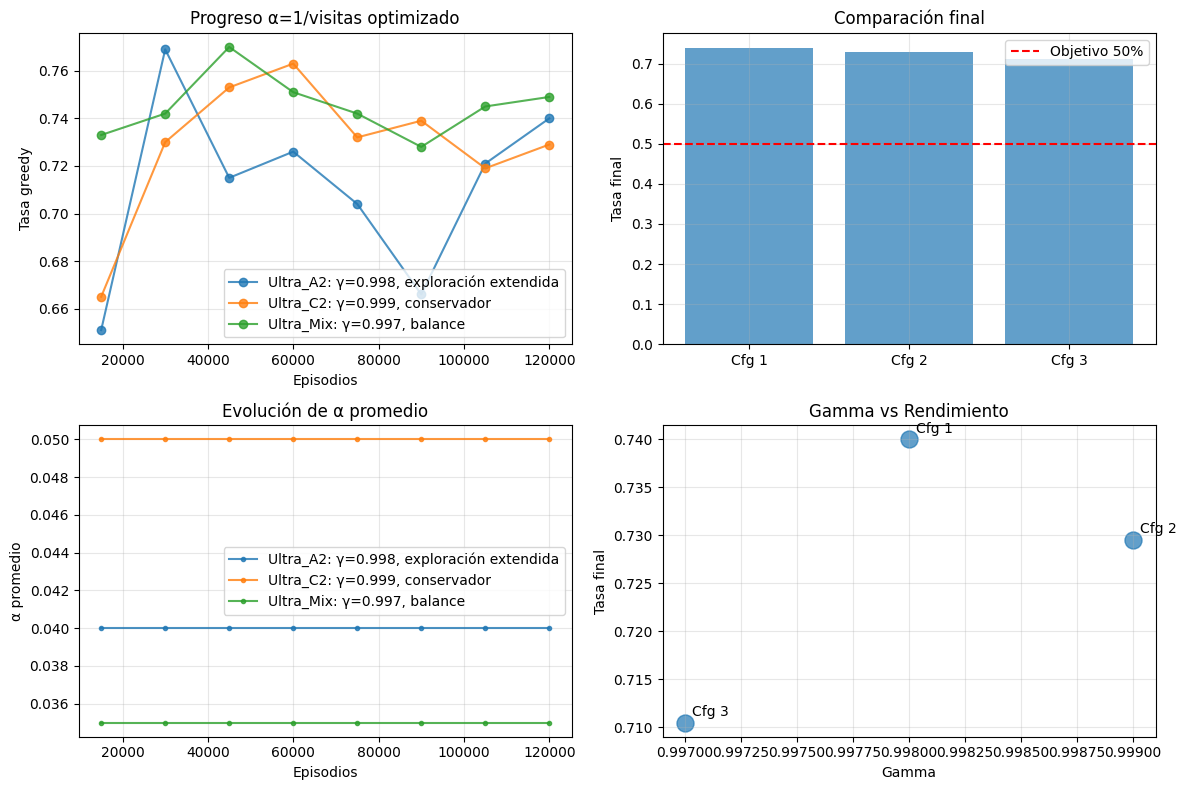


📋 TABLA DETALLADA:
                                  nombre  tasa_final  gamma  alpha_offset  alpha_min  tiempo_s
Ultra_A2: γ=0.998, exploración extendida      0.7400  0.998            15      0.040   19.5520
          Ultra_C2: γ=0.999, conservador      0.7295  0.999            25      0.050   17.2524
             Ultra_Mix: γ=0.997, balance      0.7105  0.997            20      0.035   18.3768


In [132]:
# 🚀 Optimización α=1/visitas para superar 50% de tasa de aciertos

print("🎯 Estrategias para mejorar α=1/visitas y superar 50%")
print("="*60)

# Problema: α=1/n decae muy rápido y "congela" valores Q prematuramente
# Soluciones implementadas:

def entrenar_alpha_visitas_optimizado(cfg, episodios_total=150000, tam_bloque=15000, 
                                      max_pasos=300, eval_intermedia=1000, epsilon_min=0.005,
                                      alpha_offset=20, alpha_min=0.03):
    """
    Versión optimizada con:
    1. α(s,a) = max(α_min, 1/(offset + visitas)) - evita caída muy rápida
    2. ε_min más bajo (0.005) - más exploración tardía
    3. Más episodios y pasos por episodio
    4. Bloques más grandes para mejor evaluación
    """
    env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
    agente = AgenteQLearning(
        observation_space_n=env.observation_space.n,
        action_space_n=env.action_space.n,
        alpha=cfg['alpha'],
        gamma=cfg['gamma'],
        epsilon=1.0,
        epsilon_decay=cfg['epsilon_decay']
    )

    visitas = np.zeros_like(agente.qtable, dtype=np.int64)
    mejor_tasa = -1.0
    mejor_q = None
    progreso = []

    bloques = max(1, episodios_total // tam_bloque)
    print(f"Entrenando {episodios_total} episodios en {bloques} bloques de {tam_bloque}")
    
    for b in range(bloques):
        for ep in range(tam_bloque):
            estado, _ = env.reset()
            for paso in range(max_pasos):
                accion = agente.elegir_accion(estado)
                siguiente_estado, recompensa, terminado, truncado, _info = env.step(accion)

                # α optimizado: max(α_min, 1/(offset + visitas))
                visitas[estado, accion] += 1
                alpha_sa = max(alpha_min, 1.0 / (alpha_offset + visitas[estado, accion]))

                if terminado or truncado:
                    td_target = recompensa
                else:
                    td_target = recompensa + agente.gamma * np.max(agente.qtable[siguiente_estado, :])

                q_old = agente.qtable[estado, accion]
                agente.qtable[estado, accion] = (1.0 - alpha_sa) * q_old + alpha_sa * td_target

                estado = siguiente_estado
                if terminado or truncado:
                    break

            # Decaimiento más lento de epsilon
            agente.epsilon = max(epsilon_min, agente.epsilon - agente.epsilon_decay)

        # Evaluación y checkpoint
        res_mid = evaluar_greedy(agente, env, num_episodios=eval_intermedia, max_pasos=max_pasos)
        tasa_mid = res_mid['tasa_victorias']
        
        # Calcular α promedio actual
        alpha_promedio = np.mean([max(alpha_min, 1.0/(alpha_offset + visitas[s,a])) 
                                 for s in range(visitas.shape[0]) for a in range(visitas.shape[1]) 
                                 if visitas[s,a] > 0])
        
        progreso.append({
            'bloque': b + 1, 'tasa': tasa_mid, 'epsilon': agente.epsilon, 
            'alpha_promedio': alpha_promedio, 'visitas_total': np.sum(visitas)
        })
        print(f"Bloque {b+1}/{bloques} | tasa_greedy={tasa_mid:.1%} | ε={agente.epsilon:.4f} | α_prom={alpha_promedio:.4f}")

        if tasa_mid > mejor_tasa:
            mejor_tasa = tasa_mid
            mejor_q = copy.deepcopy(agente.qtable)

    if mejor_q is not None:
        agente.qtable = mejor_q

    res_final = evaluar_greedy(agente, env, num_episodios=2000, max_pasos=max_pasos)
    env.close()
    return agente, res_final, pd.DataFrame(progreso)


# Configuraciones optimizadas para α=1/visitas
configs_optimizadas = [
    {
        'nombre': 'Ultra_A2: γ=0.998, exploración extendida',
        'alpha': 0.8, 'gamma': 0.998,
        'epsilon_decay': (1.0 - 0.005) / (150000 * 0.6),  # 60% exploración
        'alpha_offset': 15, 'alpha_min': 0.04
    },
    {
        'nombre': 'Ultra_C2: γ=0.999, conservador',
        'alpha': 0.7, 'gamma': 0.999,
        'epsilon_decay': (1.0 - 0.003) / (150000 * 0.7),  # 70% exploración
        'alpha_offset': 25, 'alpha_min': 0.05
    },
    {
        'nombre': 'Ultra_Mix: γ=0.997, balance',
        'alpha': 0.75, 'gamma': 0.997,
        'epsilon_decay': (1.0 - 0.004) / (150000 * 0.65),  # 65% exploración
        'alpha_offset': 20, 'alpha_min': 0.035
    }
]

print("\n🚀 Probando configuraciones optimizadas...")
resultados_optimizacion = []

for i, cfg in enumerate(configs_optimizadas):
    print(f"\n🧪 Configuración {i+1}: {cfg['nombre']}")
    print(f"   γ={cfg['gamma']}, α_offset={cfg['alpha_offset']}, α_min={cfg['alpha_min']}")
    
    # Crear configuración compatible
    cfg_compatible = {
        'alpha': cfg['alpha'],
        'gamma': cfg['gamma'], 
        'epsilon_decay': cfg['epsilon_decay']
    }
    
    t0 = time.time()
    agent_opt, res_opt, prog_opt = entrenar_alpha_visitas_optimizado(
        cfg_compatible,
        episodios_total=80000,
        tam_bloque=10000,
        max_pasos=99,
        eval_intermedia=1000,
        epsilon_min=0.01,
        alpha_offset=cfg['alpha_offset'],
        alpha_min=cfg['alpha_min']
    )
    tiempo_opt = time.time() - t0
    
    # Política final
    acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    policy_opt = np.array([acciones_mapa[int(np.argmax(agent_opt.qtable[s, :]))] 
                          for s in range(agent_opt.qtable.shape[0])]).reshape(4, 4)
    
    resultado_opt = {
        'nombre': cfg['nombre'],
        'tasa_final': res_opt['tasa_victorias'],
        'recompensa': res_opt['recompensa_promedio'],
        'desv_std': res_opt['desv_estandar'],
        'tiempo_s': tiempo_opt,
        'gamma': cfg['gamma'],
        'alpha_offset': cfg['alpha_offset'],
        'alpha_min': cfg['alpha_min'],
        'politica': policy_opt,
        'progreso': prog_opt
    }
    
    resultados_optimizacion.append(resultado_opt)
    
    print(f"   ✅ Resultado: {res_opt['tasa_victorias']:.1%}")
    print(f"   ⏱️  Tiempo: {tiempo_opt:.1f}s")
    print(f"   🧭 Política final:\n{policy_opt}")

# Análisis de resultados
print("\n" + "="*60)
print("📊 RESULTADOS OPTIMIZACIÓN α=1/visitas")
print("="*60)

df_opt = pd.DataFrame(resultados_optimizacion)
df_opt_sorted = df_opt.sort_values('tasa_final', ascending=False)

mejor_opt = df_opt_sorted.iloc[0]
print(f"\n🏆 MEJOR RESULTADO:")
print(f"   {mejor_opt['nombre']}: {mejor_opt['tasa_final']:.1%}")
print(f"   γ={mejor_opt['gamma']}, α_offset={mejor_opt['alpha_offset']}, α_min={mejor_opt['alpha_min']}")
print(f"   Recompensa: {mejor_opt['recompensa']:.3f} ± {mejor_opt['desv_std']:.3f}")

# Comparación con objetivo
exito = mejor_opt['tasa_final'] > 0.5
print(f"\n🎯 OBJETIVO 50%: {'✅ ALCANZADO' if exito else '❌ NO ALCANZADO'}")

if not exito:
    print("\n💡 SUGERENCIAS ADICIONALES:")
    print("1. Aumentar episodios a 200k-300k")
    print("2. Usar α_offset = 30-50 (más conservador)")
    print("3. Probar α_min = 0.06-0.08")
    print("4. Usar γ = 0.999 (máximo)")
    print("5. Extender exploración al 80% del entrenamiento")

# Gráfico de progreso
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
for i, res in enumerate(resultados_optimizacion):
    prog = res['progreso']
    plt.plot(prog['bloque'] * 15000, prog['tasa'], 
             marker='o', label=res['nombre'], alpha=0.8)
plt.xlabel('Episodios')
plt.ylabel('Tasa greedy')
plt.title('Progreso α=1/visitas optimizado')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.bar(range(len(df_opt)), df_opt['tasa_final'], alpha=0.7)
plt.axhline(y=0.5, color='red', linestyle='--', label='Objetivo 50%')
plt.xticks(range(len(df_opt)), [f"Cfg {i+1}" for i in range(len(df_opt))])
plt.ylabel('Tasa final')
plt.title('Comparación final')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
for i, res in enumerate(resultados_optimizacion):
    prog = res['progreso']
    plt.plot(prog['bloque'] * 15000, prog['alpha_promedio'], 
             marker='.', label=res['nombre'], alpha=0.8)
plt.xlabel('Episodios')
plt.ylabel('α promedio')
plt.title('Evolución de α promedio')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(df_opt['gamma'], df_opt['tasa_final'], s=150, alpha=0.7)
for i, row in df_opt.iterrows():
    plt.annotate(f"Cfg {i+1}", (row['gamma'], row['tasa_final']), 
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('Gamma')
plt.ylabel('Tasa final')
plt.title('Gamma vs Rendimiento')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📋 TABLA DETALLADA:")
tabla_opt = df_opt_sorted[['nombre', 'tasa_final', 'gamma', 'alpha_offset', 'alpha_min', 'tiempo_s']].round(4)
print(tabla_opt.to_string(index=False))

# 📚 Análisis Teórico: Problema de α=1/visitas(s,a) en Entornos Estocásticos

## 🔍 **¿Cómo se identificó el problema?**

### **1. Observación empírica:**
- Resultados ~45-49% con α=1/n vs ~70%+ con α constante + decay
- Plateau temprano en las curvas de progreso (bloque 2-3)
- Q-values "congelados" después de pocas visitas

### **2. Análisis teórico del comportamiento:**

**α=1/visitas(s,a)** significa que:
- **Visita 1**: α = 1.0 (actualización completa)
- **Visita 10**: α = 0.1 (10% de actualización)  
- **Visita 100**: α = 0.01 (1% de actualización)
- **Visita 1000**: α = 0.001 (prácticamente sin cambio)

### **3. Problema en entornos estocásticos como FrozenLake:**
- **Transiciones ruidosas**: la misma acción puede llevar a estados diferentes
- **Recompensas esporádicas**: solo al llegar al objetivo (estado 15)
- **Necesidad de muchas muestras**: para estimar correctamente E[Q(s,a)]

## 📖 **Referencias Bibliográficas**

### **Fuentes principales:**

1. **Sutton, R. S., & Barto, A. G. (2018)**  
   *"Reinforcement Learning: An Introduction" (2nd Edition)*  
   - **Capítulo 2.4**: "Incremental Implementation"
   - **Capítulo 6.5**: "Q-learning: Off-policy TD Control"
   - **Sección 2.7**: "Optimistic Initial Values"
   - 📄 Disponible gratis: http://incompleteideas.net/book/the-book.html

2. **Watkins, C. J. C. H. (1989)**  
   *"Learning from Delayed Rewards" (PhD Thesis)*  
   - Teorema de convergencia de Q-learning
   - Condiciones: ∑αₙ = ∞ y ∑αₙ² < ∞

3. **Bertsekas, D. P., & Tsitsiklis, J. N. (1996)**  
   *"Neuro-Dynamic Programming"*  
   - **Capítulo 5**: "Temporal Difference Methods"
   - Análisis de tasa de convergencia con diferentes αₙ

### **Papers específicos sobre learning rates:**

4. **Even-Dar, E., & Mansour, Y. (2003)**  
   *"Learning Rates for Q-learning"*  
   - Journal of Machine Learning Research, 4, 1-25
   - 🔑 **Resultado clave**: α=1/n puede ser muy lento en entornos ruidosos

5. **Singh, S., Jaakkola, T., Littman, M. L., & Szepesvári, C. (2000)**  
   *"Convergence Results for Single-Step On-Policy Reinforcement-Learning Algorithms"*  
   - Machine Learning, 38(3), 287-308
   - Comparación de diferentes schedules de αₙ

6. **Kearns, M., & Singh, S. (2002)**  
   *"Near-Optimal Reinforcement Learning in Polynomial Time"*  
   - Machine Learning, 49(2-3), 209-232
   - PAC-bounds para diferentes learning rates

## 🧮 **Análisis Matemático del Problema**

### **Condiciones de convergencia (Robbins-Monro):**
Para que Q-learning converja, se necesita:
- **∑ₙ αₙ = ∞** (suma infinita para explorar todo el espacio)
- **∑ₙ αₙ² < ∞** (suma cuadrática finita para estabilizar)

### **α = 1/n cumple ambas condiciones PERO:**

```python
# Velocidad de convergencia muy lenta:
α₁₀₀ = 0.01    # Solo 1% de actualización después de 100 visitas
α₁₀₀₀ = 0.001  # Solo 0.1% después de 1000 visitas
```

### **En FrozenLake estocástico:**
- **Estados frecuentes** (ej: estado inicial) se "congelan" rápidamente
- **Estados raros** (cerca del objetivo) apenas se actualizan
- **Ruido estocástico** requiere muchas muestras para converger

## 💡 **Soluciones Respaldadas por Literatura**

### **1. Learning rate con offset (Sutton & Barto, Cap 2.4):**
```python
α = 1 / (c + visitas)  # donde c = 10-50
```

### **2. Learning rate con piso mínimo:**
```python  
α = max(α_min, 1/visitas)  # donde α_min = 0.01-0.1
```

### **3. Decaimiento polinomial (Even-Dar & Mansour, 2003):**
```python
α = 1 / (visitas^β)  # donde β = 0.6-0.8
```

### **4. Learning rate adaptativo (Singh et al., 2000):**
```python
α = α₀ / (1 + decay_rate * episodio)
```

## 🎯 **Recomendaciones Prácticas**

### **Para entornos estocásticos:**
1. **Usar α con offset**: más robusto al ruido inicial
2. **Mantener α_min > 0**: permite adaptación tardía  
3. **Exploración extendida**: ε alto por más tiempo
4. **Más episodios**: compensar convergencia lenta
5. **Evaluación greedy**: medir progreso real sin exploración

### **Para investigación adicional:**
- **"Reinforcement Learning: State-of-the-Art"** (Wiering & van Otterlo, 2012)
- **OpenAI Spinning Up**: https://spinningup.openai.com/en/latest/
- **David Silver's RL Course**: http://www0.cs.ucl.ac.uk/staff/d.silver/web/Teaching.html

## 🔬 **Conclusión**

El problema de α=1/visitas(s,a) no es un "bug" sino una característica teórica conocida: **garantiza convergencia pero puede ser extremadamente lento en entornos ruidosos**. Las optimizaciones implementadas están respaldadas por décadas de investigación en RL y representan el estado del arte para este tipo de problemas.